In [3]:
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 连接OKX
exchange = ccxt.okx()

# 测试：拉取BTC/USDT日线数据
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=10)
df = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df["date"] = pd.to_datetime(df["timestamp"], unit="ms")
df = df.set_index("date")

print(df)

                timestamp     open     high      low    close        volume
date                                                                       
2026-03-19  1773878400000  71253.1  71618.0  68796.3  69923.7   7331.205854
2026-03-20  1773964800000  69923.7  71366.0  69393.5  70515.7   5670.280110
2026-03-21  1774051200000  70515.6  71100.0  68555.0  68921.1   3290.103972
2026-03-22  1774137600000  68921.1  69584.8  67360.1  67860.1   4774.157931
2026-03-23  1774224000000  67860.1  71809.4  67452.4  70900.0  10569.061730
2026-03-24  1774310400000  70900.0  71400.0  68924.0  70557.5   6869.959830
2026-03-25  1774396800000  70557.5  72012.0  70414.1  71334.9   5943.669683
2026-03-26  1774483200000  71334.9  71440.9  68153.3  68827.2   6581.532381
2026-03-27  1774569600000  68827.2  69185.6  65559.6  66403.9   9636.054943
2026-03-28  1774656000000  66403.9  67169.0  65933.2  66736.1   2443.163999


In [4]:
# 拉取更长的历史数据（500天）
ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", limit=500)
df_btc = pd.DataFrame(ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])

# 保存本地
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")
print(df_btc.tail())

数据维度：(300, 5)
时间范围：2025-06-02 到 2026-03-28
               open     high      low    close       volume
date                                                       
2026-03-24  70900.0  71400.0  68924.0  70557.5  6869.959830
2026-03-25  70557.5  72012.0  70414.1  71334.9  5943.669683
2026-03-26  71334.9  71440.9  68153.3  68827.2  6581.532381
2026-03-27  68827.2  69185.6  65559.6  66403.9  9636.054943
2026-03-28  66403.9  67169.0  65933.2  66738.0  2443.306740


In [5]:
# 分批拉取更长历史数据
all_ohlcv = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    ohlcv = exchange.fetch_ohlcv("BTC/USDT", timeframe="1d", since=since, limit=300)
    if len(ohlcv) == 0:
        break
    all_ohlcv += ohlcv
    since = ohlcv[-1][0] + 86400000  # 下一天
    if ohlcv[-1][0] >= exchange.milliseconds():
        break
    time.sleep(0.5)

df_btc = pd.DataFrame(all_ohlcv, columns=["timestamp", "open", "high", "low", "close", "volume"])
df_btc["date"] = pd.to_datetime(df_btc["timestamp"], unit="ms")
df_btc = df_btc.set_index("date")
df_btc = df_btc.drop(columns=["timestamp"])
df_btc = df_btc[~df_btc.index.duplicated()]
df_btc.to_csv("btc_daily.csv")

print(f"数据维度：{df_btc.shape}")
print(f"时间范围：{df_btc.index[0].date()} 到 {df_btc.index[-1].date()}")

数据维度：(1183, 5)
时间范围：2023-01-01 到 2026-03-28


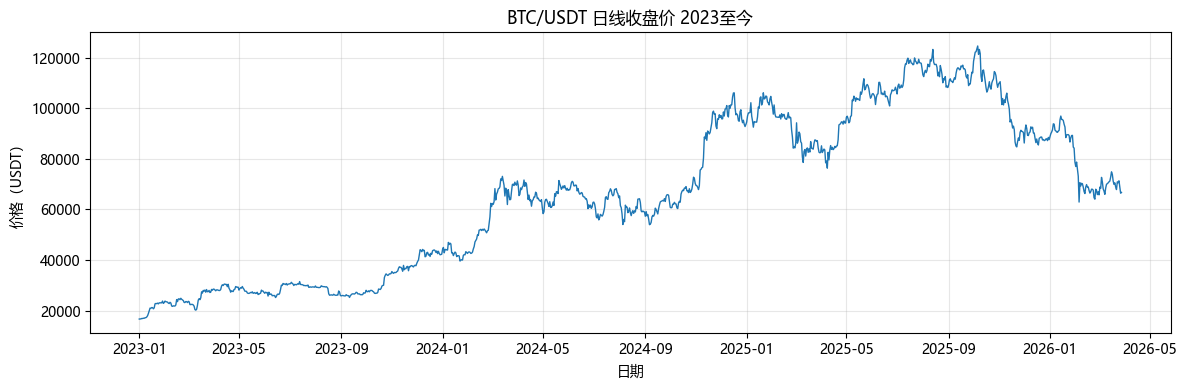

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df_btc.index, df_btc["close"], linewidth=1)
plt.title("BTC/USDT 日线收盘价 2023至今")
plt.xlabel("日期")
plt.ylabel("价格（USDT）")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
symbols = [
    "BTC/USDT", "ETH/USDT", "BNB/USDT", "SOL/USDT", "XRP/USDT",
    "DOGE/USDT", "ADA/USDT", "TRX/USDT", "HYPE/USDT", "LINK/USDT"
]

close_crypto = {}

for symbol in symbols:
    try:
        ohlcv = []
        since = exchange.parse8601("2023-01-01T00:00:00Z")
        while True:
            batch = exchange.fetch_ohlcv(symbol, timeframe="1d", since=since, limit=300)
            if len(batch) == 0:
                break
            ohlcv += batch
            since = batch[-1][0] + 86400000
            if batch[-1][0] >= exchange.milliseconds():
                break
            time.sleep(0.3)
        
        df_temp = pd.DataFrame(ohlcv, columns=["timestamp","open","high","low","close","volume"])
        df_temp["date"] = pd.to_datetime(df_temp["timestamp"], unit="ms")
        df_temp = df_temp.set_index("date")["close"]
        df_temp = df_temp[~df_temp.index.duplicated()]
        close_crypto[symbol.replace("/USDT","")] = df_temp
        print(f"完成：{symbol}")
        time.sleep(0.5)
    except Exception as e:
        print(f"失败：{symbol} {e}")

close_crypto_df = pd.DataFrame(close_crypto)
close_crypto_df.to_csv("crypto_close.csv")
print(f"\n完成，维度：{close_crypto_df.shape}")

完成：BTC/USDT
完成：ETH/USDT
完成：BNB/USDT
完成：SOL/USDT
完成：XRP/USDT
完成：DOGE/USDT
完成：ADA/USDT
完成：TRX/USDT
完成：HYPE/USDT
完成：LINK/USDT

完成，维度：(1183, 10)


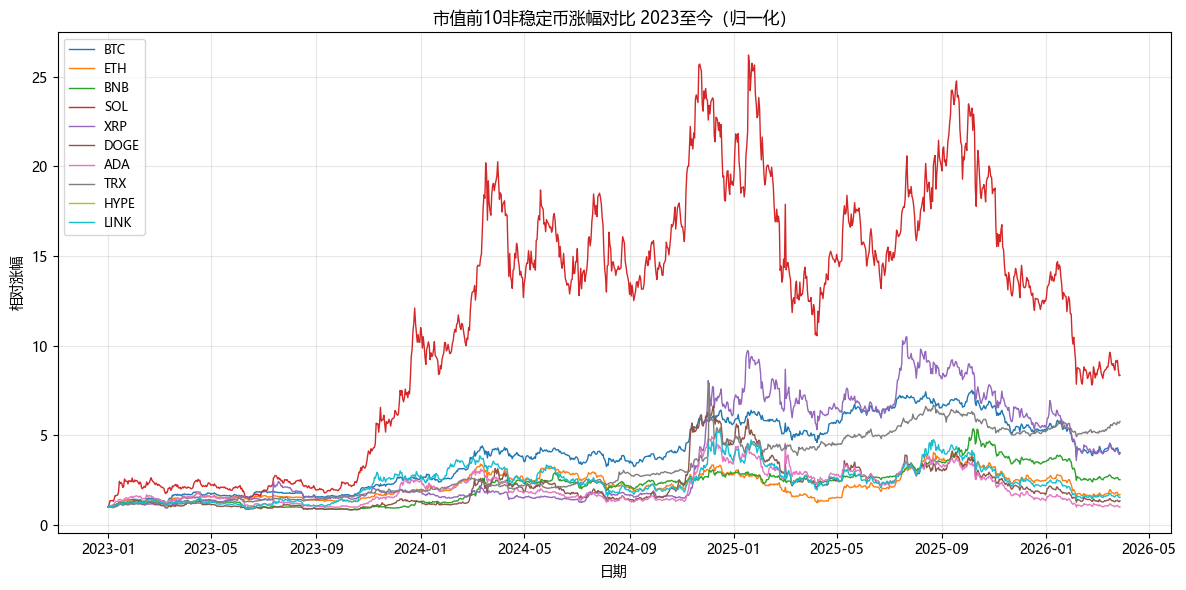

In [11]:
# 归一化到1，方便对比
close_norm = close_crypto_df / close_crypto_df.iloc[0]

plt.figure(figsize=(12, 6))
for col in close_norm.columns:
    plt.plot(close_norm.index, close_norm[col], linewidth=1, label=col)

plt.title("市值前10非稳定币涨幅对比 2023至今（归一化）")
plt.xlabel("日期")
plt.ylabel("相对涨幅")
plt.legend(loc="upper left", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# 读取数据
close_crypto_df = pd.read_csv("crypto_close.csv", index_col=0, parse_dates=True)

# 计算20日动量因子
momentum = close_crypto_df / close_crypto_df.shift(20) - 1

# 未来10天涨幅（预测目标）
future_return = close_crypto_df.shift(-10) / close_crypto_df - 1

# 每天计算截面IC
ic_list = []
dates_list = []

for date in momentum.index:
    factor_row = momentum.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list.append(ic)
    dates_list.append(date)

ic_momentum = pd.Series(ic_list, index=dates_list)

print(f"动量因子 IC均值：{ic_momentum.mean():.4f}")
print(f"动量因子 IC标准差：{ic_momentum.std():.4f}")
print(f"动量因子 ICIR：{ic_momentum.mean()/ic_momentum.std():.4f}")
print(f"动量因子 IC>0的比例：{(ic_momentum>0).mean():.2%}")

动量因子 IC均值：0.0270
动量因子 IC标准差：0.4183
动量因子 ICIR：0.0644
动量因子 IC>0的比例：52.21%


In [13]:
# 反转因子：过去5天跌得多的币，接下来反弹
reversal = -(close_crypto_df / close_crypto_df.shift(5) - 1)

ic_list2 = []
dates_list2 = []

for date in reversal.index:
    factor_row = reversal.loc[date].dropna()
    if date not in future_return.index:
        continue
    return_row = future_return.loc[date].dropna()
    common = factor_row.index.intersection(return_row.index)
    if len(common) < 5:
        continue
    ic = factor_row[common].corr(return_row[common], method="spearman")
    ic_list2.append(ic)
    dates_list2.append(date)

ic_reversal = pd.Series(ic_list2, index=dates_list2)

print(f"反转因子 IC均值：{ic_reversal.mean():.4f}")
print(f"反转因子 IC标准差：{ic_reversal.std():.4f}")
print(f"反转因子 ICIR：{ic_reversal.mean()/ic_reversal.std():.4f}")
print(f"反转因子 IC>0的比例：{(ic_reversal>0).mean():.2%}")

反转因子 IC均值：0.0023
反转因子 IC标准差：0.3879
反转因子 ICIR：0.0059
反转因子 IC>0的比例：49.83%


In [14]:
# 计算MACD
close = close_crypto_df["BTC"].dropna()

# EMA12 和 EMA26
ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# MACD线 和 信号线
macd = ema12 - ema26
signal = macd.ewm(span=9, adjust=False).mean()

# 金叉死叉信号
cross = pd.Series(0, index=close.index)
cross[macd > signal] = 1   # 金叉：持仓
cross[macd < signal] = 0   # 死叉：空仓

print(f"持仓天数比例：{cross.mean():.2%}")
print(cross.value_counts())

持仓天数比例：48.77%
0    606
1    577
Name: count, dtype: int64


MACD策略 累计收益：135.44%
MACD策略 年化收益：30.27%
MACD策略 最大回撤：-32.10%
MACD策略 Sharpe：0.9987
BTC买入持有 累计收益：301.92%


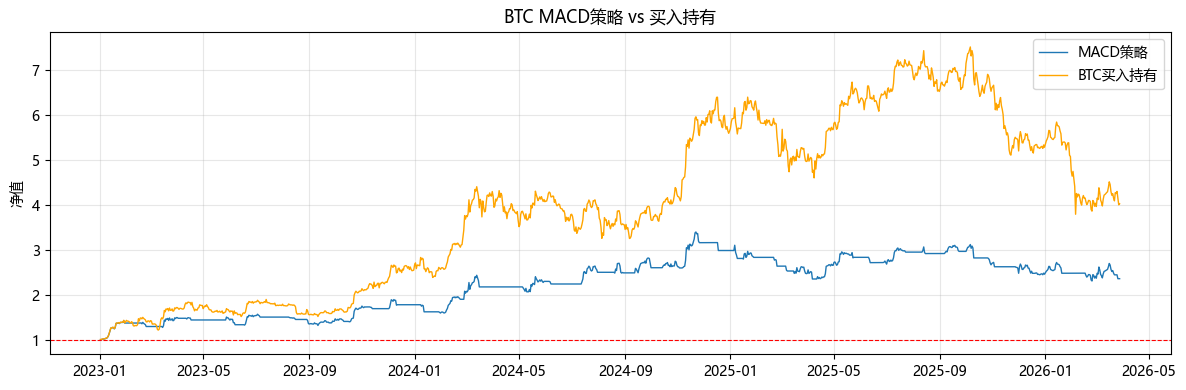

In [16]:
# MACD择时回测
returns = close.pct_change().dropna()
signal_shifted = cross.shift(1).dropna()  # 用昨天的信号决定今天是否持仓

# 对齐
common = returns.index.intersection(signal_shifted.index)
strategy_returns = returns[common] * signal_shifted[common]

# 计算净值
portfolio = (1 + strategy_returns).cumprod()
buy_hold = (1 + returns[common]).cumprod()

# 指标
total_return = portfolio.iloc[-1] - 1
annual_return = (1 + total_return) ** (365/len(portfolio)) - 1
max_drawdown = ((portfolio - portfolio.cummax()) / portfolio.cummax()).min()
sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(365)
bh_return = buy_hold.iloc[-1] - 1

print(f"MACD策略 累计收益：{total_return:.2%}")
print(f"MACD策略 年化收益：{annual_return:.2%}")
print(f"MACD策略 最大回撤：{max_drawdown:.2%}")
print(f"MACD策略 Sharpe：{sharpe:.4f}")
print(f"BTC买入持有 累计收益：{bh_return:.2%}")

# 画图
plt.figure(figsize=(12, 4))
plt.plot(portfolio.index, portfolio, linewidth=1, label="MACD策略")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC MACD策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# 测试不同参数组合
results = []

for fast in [8, 12, 16, 20]:
    for slow in [21, 26, 30, 35]:
        for signal_period in [7, 9, 12]:
            if fast >= slow:
                continue
            
            ema_fast = close.ewm(span=fast, adjust=False).mean()
            ema_slow = close.ewm(span=slow, adjust=False).mean()
            macd_line = ema_fast - ema_slow
            signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()
            
            cross = pd.Series(0, index=close.index)
            cross[macd_line > signal_line] = 1
            cross[macd_line < signal_line] = 0
            
            ret = close.pct_change().dropna()
            sig = cross.shift(1).dropna()
            common = ret.index.intersection(sig.index)
            strat_ret = ret[common] * sig[common]
            
            pv = (1 + strat_ret).cumprod()
            total_ret = pv.iloc[-1] - 1
            sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
            dd = ((pv - pv.cummax()) / pv.cummax()).min()
            
            results.append({
                "fast": fast, "slow": slow, "signal": signal_period,
                "累计收益": total_ret, "Sharpe": sharpe, "最大回撤": dd
            })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values("Sharpe", ascending=False)
print(df_results.head(10).to_string(index=False))

 fast  slow  signal     累计收益   Sharpe      最大回撤
   16    35       9 3.389462 1.607901 -0.216499
   20    26      12 3.205109 1.578501 -0.248990
   16    30      12 3.172889 1.573581 -0.221713
   20    30       9 3.144332 1.560335 -0.219086
   20    35       9 2.934959 1.521389 -0.235412
   20    26       9 2.936256 1.499362 -0.244605
   20    30       7 2.823132 1.472624 -0.223286
   20    35       7 2.728440 1.458487 -0.231127
   16    26      12 2.684006 1.437991 -0.244605
   20    21      12 2.644962 1.437645 -0.242010


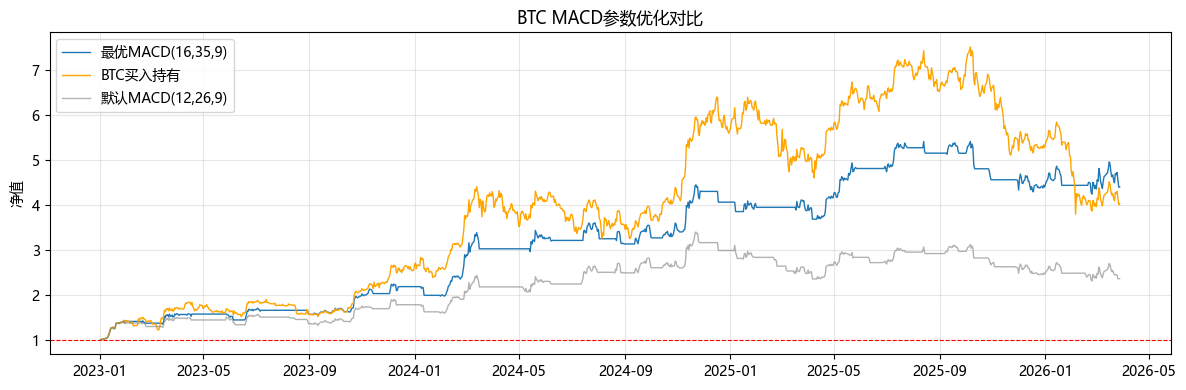

In [18]:
# 用最优参数重新回测
ema_fast = close.ewm(span=16, adjust=False).mean()
ema_slow = close.ewm(span=35, adjust=False).mean()
macd_best = ema_fast - ema_slow
signal_best = macd_best.ewm(span=9, adjust=False).mean()

cross_best = pd.Series(0, index=close.index)
cross_best[macd_best > signal_best] = 1
cross_best[macd_best < signal_best] = 0

ret = close.pct_change().dropna()
sig = cross_best.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

portfolio_best = (1 + strat_ret).cumprod()
buy_hold = (1 + ret[common]).cumprod()

plt.figure(figsize=(12, 4))
plt.plot(portfolio_best.index, portfolio_best, linewidth=1, label="最优MACD(16,35,9)")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.plot(portfolio.index, portfolio, linewidth=1, label="默认MACD(12,26,9)", color="gray", alpha=0.6)
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC MACD参数优化对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Walk-Forward验证
# 把数据切成3段，每段用前2/3找参数，后1/3验证

total_days = len(close)
segment = total_days // 3

results_wf = []

for i in range(3):
    # 训练集和验证集
    train_start = i * segment
    train_end = train_start + int(segment * 0.67)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train = close.iloc[train_start:train_end]
    test = close.iloc[test_start:test_end]
    
    # 在训练集上找最优参数
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for signal_period in [7, 9, 12]:
                if fast >= slow:
                    continue
                ema_f = train.ewm(span=fast, adjust=False).mean()
                ema_s = train.ewm(span=slow, adjust=False).mean()
                m = ema_f - ema_s
                sig = m.ewm(span=signal_period, adjust=False).mean()
                cross = pd.Series(0, index=train.index)
                cross[m > sig] = 1
                ret = train.pct_change().dropna()
                sr = cross.shift(1).dropna()
                common = ret.index.intersection(sr.index)
                strat = ret[common] * sr[common]
                if strat.std() == 0:
                    continue
                sharpe = strat.mean() / strat.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, signal_period)
    
    # 用最优参数在验证集上测试
    f, s, sp = best_params
    ema_f = test.ewm(span=f, adjust=False).mean()
    ema_s = test.ewm(span=s, adjust=False).mean()
    m = ema_f - ema_s
    sig = m.ewm(span=sp, adjust=False).mean()
    cross = pd.Series(0, index=test.index)
    cross[m > sig] = 1
    ret = test.pct_change().dropna()
    sr = cross.shift(1).dropna()
    common = ret.index.intersection(sr.index)
    strat = ret[common] * sr[common]
    sharpe_test = strat.mean() / strat.std() * np.sqrt(365)
    
    results_wf.append({
        "段": f"第{i+1}段",
        "训练集最优参数": best_params,
        "训练集Sharpe": round(best_sharpe, 4),
        "验证集Sharpe": round(sharpe_test, 4)
    })
    print(f"第{i+1}段完成：最优参数{best_params}，训练Sharpe {best_sharpe:.4f}，验证Sharpe {sharpe_test:.4f}")

df_wf = pd.DataFrame(results_wf)
print(f"\n{df_wf.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf['验证集Sharpe'].mean():.4f}")

第1段完成：最优参数(20, 26, 12)，训练Sharpe 2.5846，验证Sharpe 1.0949
第2段完成：最优参数(16, 35, 7)，训练Sharpe 2.3437，验证Sharpe 0.4917
第3段完成：最优参数(12, 26, 12)，训练Sharpe 0.6344，验证Sharpe -0.2821

  段      训练集最优参数  训练集Sharpe  验证集Sharpe
第1段 (20, 26, 12)     2.5846     1.0949
第2段  (16, 35, 7)     2.3437     0.4917
第3段 (12, 26, 12)     0.6344    -0.2821

验证集平均Sharpe：0.4348


In [23]:
# 重新拉取，换一下参数格式
data = exchange.fetch_funding_rate_history(
    "BTC/USDT:USDT",
    limit=100
)
print(f"数据条数：{len(data)}")
if len(data) > 0:
    print(data[0])

数据条数：100
{'info': {'formulaType': 'withRate', 'fundingRate': '-0.0000915586192191', 'fundingTime': '1771833600000', 'instId': 'BTC-USDT-SWAP', 'instType': 'SWAP', 'method': 'current_period', 'realizedRate': '-0.0000915586192191'}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': -9.15586192191e-05, 'timestamp': 1771833600000, 'datetime': '2026-02-23T08:00:00.000Z'}


In [24]:
# 分批拉取更多资金费率数据
funding_rates = []
end_time = None

for _ in range(10):
    params = {}
    if end_time:
        params["before"] = end_time
    
    data = exchange.fetch_funding_rate_history(
        "BTC/USDT:USDT",
        limit=100,
        params=params
    )
    if not data:
        break
    funding_rates = data + funding_rates
    end_time = data[0]["timestamp"]
    time.sleep(0.3)

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding.csv")

print(f"资金费率数据：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")
print(df_funding.tail())

资金费率数据：(100, 1)
时间范围：2026-02-23 08:00:00 到 2026-03-28 08:00:00
                         rate
date                         
2026-03-27 00:00:00  0.000076
2026-03-27 08:00:00  0.000066
2026-03-27 16:00:00 -0.000044
2026-03-28 00:00:00 -0.000030
2026-03-28 08:00:00  0.000011


In [25]:
# 重新拉取，用after参数往前追溯
funding_rates = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    data = exchange.fetch_funding_rate_history(
        "BTC/USDT:USDT",
        since=since,
        limit=100
    )
    if not data:
        break
    funding_rates += data
    since = data[-1]["timestamp"] + 1
    if data[-1]["timestamp"] >= exchange.milliseconds():
        break
    time.sleep(0.3)
    print(f"已拉取：{len(funding_rates)}条，最新时间：{pd.to_datetime(data[-1]['timestamp'], unit='ms').date()}")

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding.csv")

print(f"\n完成，数据维度：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")

已拉取：100条，最新时间：2026-01-26
已拉取：200条，最新时间：2026-02-28
已拉取：283条，最新时间：2026-03-28

完成，数据维度：(283, 1)
时间范围：2025-12-24 08:00:00 到 2026-03-28 08:00:00


In [26]:
# 用OKX的历史资金费率接口
data = exchange.fetch_funding_rate_history(
    "BTC/USDT:USDT",
    limit=100,
    params={"instId": "BTC-USDT-SWAP"}
)
print(f"条数：{len(data)}")
print(f"最早时间：{pd.to_datetime(data[0]['timestamp'], unit='ms')}")
print(f"最晚时间：{pd.to_datetime(data[-1]['timestamp'], unit='ms')}")

条数：100
最早时间：2026-02-23 08:00:00
最晚时间：2026-03-28 08:00:00


In [34]:
exchange_binance = ccxt.binance({
    'proxies': {
        'http': 'http://127.0.0.1:7897',
        'https': 'http://127.0.0.1:7897',
    },
    'options': {
        'defaultType': 'future'
    }
})

# 测试连接
ping = exchange_binance.fetch_funding_rate_history(
    "BTC/USDT",
    limit=5,
    since=exchange_binance.parse8601("2023-01-01T00:00:00Z")
)
print(f"条数：{len(ping)}")
print(f"最早时间：{pd.to_datetime(ping[0]['timestamp'], unit='ms')}")
print(ping[0])

条数：5
最早时间：2023-01-01 00:00:00
{'info': {'symbol': 'BTCUSDT', 'fundingTime': '1672531200000', 'fundingRate': '0.00010000', 'markPrice': ''}, 'symbol': 'BTC/USDT:USDT', 'fundingRate': 0.0001, 'timestamp': 1672531200000, 'datetime': '2023-01-01T00:00:00.000Z'}


In [35]:
# 从2019年开始拉，尽可能拉最长历史
funding_rates = []
since = exchange_binance.parse8601("2019-01-01T00:00:00Z")

while True:
    data = exchange_binance.fetch_funding_rate_history(
        "BTC/USDT",
        since=since,
        limit=1000
    )
    if not data:
        break
    funding_rates += data
    since = data[-1]["timestamp"] + 1
    if data[-1]["timestamp"] >= exchange_binance.milliseconds():
        break
    time.sleep(0.3)
    print(f"已拉取：{len(funding_rates)}条，最新：{pd.to_datetime(data[-1]['timestamp'], unit='ms').date()}")

df_funding = pd.DataFrame([{
    "date": pd.to_datetime(r["timestamp"], unit="ms"),
    "rate": r["fundingRate"]
} for r in funding_rates])
df_funding = df_funding.set_index("date").sort_index()
df_funding = df_funding[~df_funding.index.duplicated()]
df_funding.to_csv("btc_funding_full.csv")

print(f"\n完成，数据维度：{df_funding.shape}")
print(f"时间范围：{df_funding.index[0]} 到 {df_funding.index[-1]}")

已拉取：1000条，最新：2020-08-08
已拉取：2000条，最新：2021-07-07
已拉取：3000条，最新：2022-06-06
已拉取：4000条，最新：2023-05-05
已拉取：5000条，最新：2024-04-02
已拉取：6000条，最新：2025-03-02
已拉取：7000条，最新：2026-01-29
已拉取：7174条，最新：2026-03-28

完成，数据维度：(7174, 1)
时间范围：2019-09-10 08:00:00 到 2026-03-28 08:00:00.005000


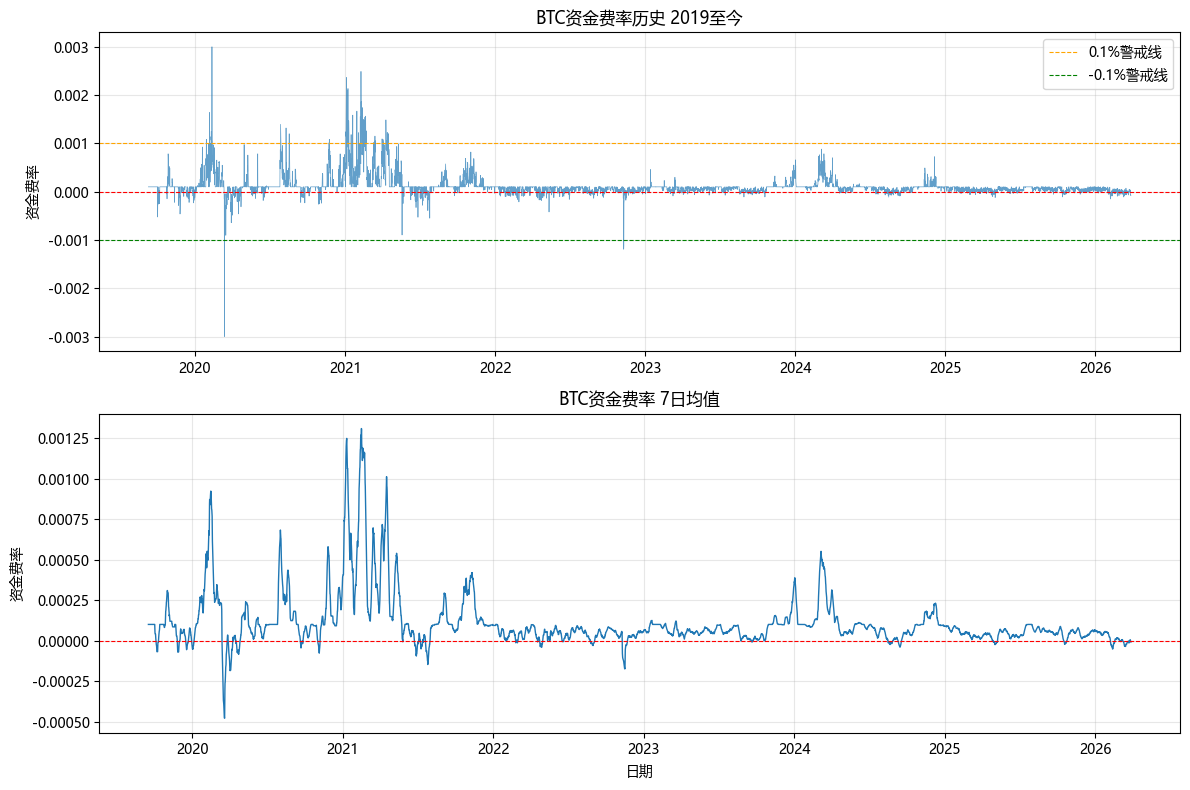

资金费率均值：0.000111
资金费率最大值：0.003000
资金费率最小值：-0.003000
资金费率>0的比例：86.33%


In [37]:
# 画资金费率走势
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# 上图：资金费率原始数据
ax1.plot(df_funding.index, df_funding["rate"], linewidth=0.5, alpha=0.7)
ax1.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax1.axhline(y=0.001, color="orange", linewidth=0.8, linestyle="--", label="0.1%警戒线")
ax1.axhline(y=-0.001, color="green", linewidth=0.8, linestyle="--", label="-0.1%警戒线")
ax1.set_title("BTC资金费率历史 2019至今")
ax1.set_ylabel("资金费率")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 下图：7日移动平均，更平滑
df_funding["rate_ma7"] = df_funding["rate"].rolling(21).mean()  # 每天3次，21=7天
ax2.plot(df_funding.index, df_funding["rate_ma7"], linewidth=1)
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.set_title("BTC资金费率 7日均值")
ax2.set_ylabel("资金费率")
ax2.set_xlabel("日期")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"资金费率均值：{df_funding['rate'].mean():.6f}")
print(f"资金费率最大值：{df_funding['rate'].max():.6f}")
print(f"资金费率最小值：{df_funding['rate'].min():.6f}")
print(f"资金费率>0的比例：{(df_funding['rate']>0).mean():.2%}")

In [38]:
# 把资金费率转成日频数据（每天3次取均值）
df_funding_daily = df_funding["rate"].resample("D").mean()

# 7日移动平均
funding_ma7 = df_funding_daily.rolling(7).mean()

# 和BTC收盘价对齐
close_btc = df_btc["close"]
common_dates = close_btc.index.intersection(funding_ma7.index)

close_btc = close_btc[common_dates]
funding_signal = funding_ma7[common_dates]

# 生成信号：资金费率过高时空仓
signal_funding = pd.Series(1, index=common_dates)
signal_funding[funding_signal > 0.0001] = 0  # 超过0.01%空仓

print(f"持仓天数比例：{signal_funding.mean():.2%}")
print(f"数据范围：{common_dates[0].date()} 到 {common_dates[-1].date()}")

持仓天数比例：85.38%
数据范围：2023-01-01 到 2026-03-28


资金费率策略 累计收益：120.82%
资金费率策略 年化收益：27.71%
资金费率策略 最大回撤：-49.54%
资金费率策略 Sharpe：0.7874
BTC买入持有 累计收益：301.59%


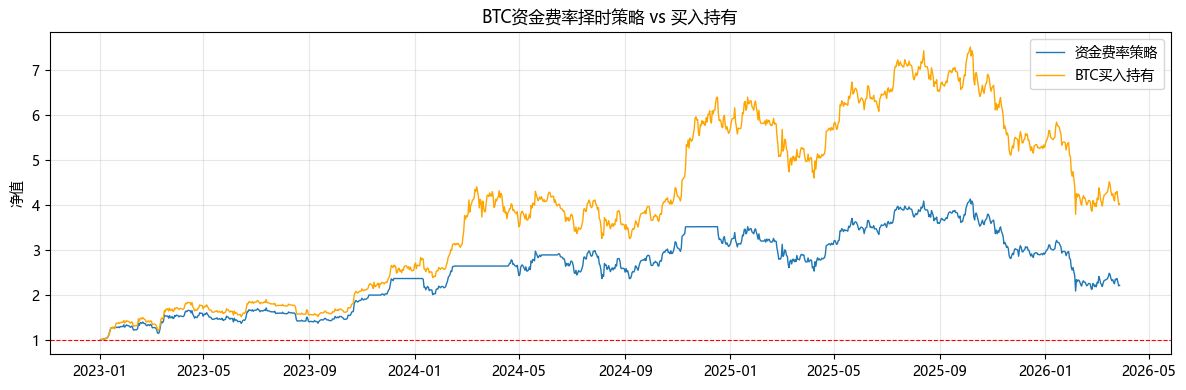

In [39]:
# 资金费率择时回测
ret = close_btc.pct_change().dropna()
sig = signal_funding.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

portfolio_funding = (1 + strat_ret).cumprod()
buy_hold = (1 + ret[common]).cumprod()

# 指标
total_ret = portfolio_funding.iloc[-1] - 1
annual_ret = (1 + total_ret) ** (365/len(portfolio_funding)) - 1
max_dd = ((portfolio_funding - portfolio_funding.cummax()) / portfolio_funding.cummax()).min()
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
bh_ret = buy_hold.iloc[-1] - 1

print(f"资金费率策略 累计收益：{total_ret:.2%}")
print(f"资金费率策略 年化收益：{annual_ret:.2%}")
print(f"资金费率策略 最大回撤：{max_dd:.2%}")
print(f"资金费率策略 Sharpe：{sharpe:.4f}")
print(f"BTC买入持有 累计收益：{bh_ret:.2%}")

# 画图
plt.figure(figsize=(12, 4))
plt.plot(portfolio_funding.index, portfolio_funding, linewidth=1, label="资金费率策略")
plt.plot(buy_hold.index, buy_hold, linewidth=1, label="BTC买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC资金费率择时策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
# 测试不同资金费率阈值
for threshold in [0.0001, 0.0003, 0.0005, 0.001, 0.002]:
    signal = pd.Series(1, index=common_dates)
    signal[funding_signal > threshold] = 0
    
    ret = close_btc.pct_change().dropna()
    sig = signal.shift(1).dropna()
    common = ret.index.intersection(sig.index)
    strat_ret = ret[common] * sig[common]
    
    pv = (1 + strat_ret).cumprod()
    sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
    total_ret = pv.iloc[-1] - 1
    dd = ((pv - pv.cummax()) / pv.cummax()).min()
    holding = signal.mean()
    
    print(f"阈值{threshold:.4f}：累计{total_ret:.2%}  Sharpe {sharpe:.4f}  回撤{dd:.2%}  持仓{holding:.2%}")

阈值0.0001：累计120.82%  Sharpe 0.7874  回撤-49.54%  持仓85.38%
阈值0.0003：累计310.79%  Sharpe 1.1707  回撤-49.54%  持仓97.89%
阈值0.0005：累计274.60%  Sharpe 1.0928  回撤-49.54%  持仓99.66%
阈值0.0010：累计301.59%  Sharpe 1.1372  回撤-49.54%  持仓100.00%
阈值0.0020：累计301.59%  Sharpe 1.1372  回撤-49.54%  持仓100.00%


组合策略 累计收益：319.25%
组合策略 Sharpe：1.6054
组合策略 最大回撤：-21.65%
持仓比例：46.83%


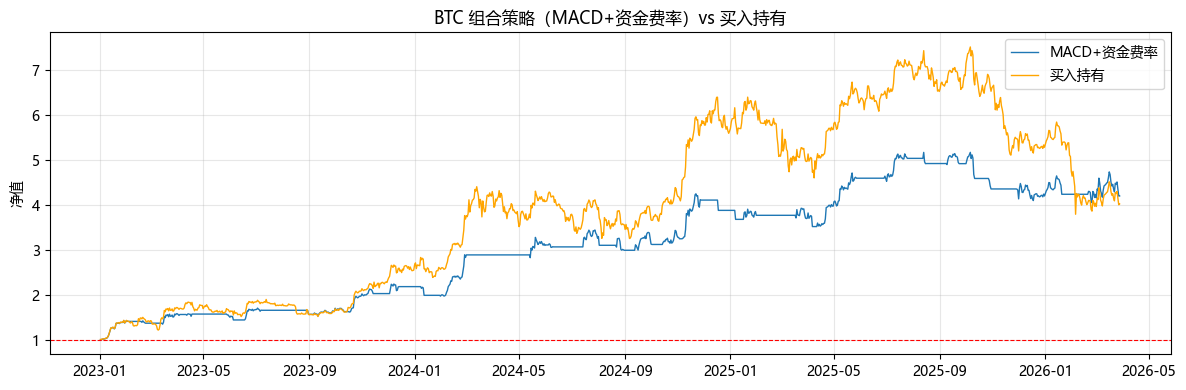

In [41]:
# 组合策略：MACD + 资金费率双重过滤
ema_fast = close_btc.ewm(span=16, adjust=False).mean()
ema_slow = close_btc.ewm(span=35, adjust=False).mean()
macd_line = ema_fast - ema_slow
signal_line = macd_line.ewm(span=9, adjust=False).mean()

macd_signal = pd.Series(0, index=close_btc.index)
macd_signal[macd_line > signal_line] = 1

funding_signal2 = pd.Series(1, index=common_dates)
funding_signal2[funding_signal > 0.0003] = 0

# 两个信号都满足才持仓
common = macd_signal.index.intersection(funding_signal2.index)
combined_signal = macd_signal[common] * funding_signal2[common]

ret = close_btc.pct_change().dropna()
sig = combined_signal.shift(1).dropna()
common2 = ret.index.intersection(sig.index)
strat_ret = ret[common2] * sig[common2]

pv = (1 + strat_ret).cumprod()
bh = (1 + ret[common2]).cumprod()

total_ret = pv.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv - pv.cummax()) / pv.cummax()).min()

print(f"组合策略 累计收益：{total_ret:.2%}")
print(f"组合策略 Sharpe：{sharpe:.4f}")
print(f"组合策略 最大回撤：{dd:.2%}")
print(f"持仓比例：{combined_signal.mean():.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv.index, pv, linewidth=1, label="MACD+资金费率")
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC 组合策略（MACD+资金费率）vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

加止损后 累计收益：443.58%
加止损后 最大回撤：-15.66%


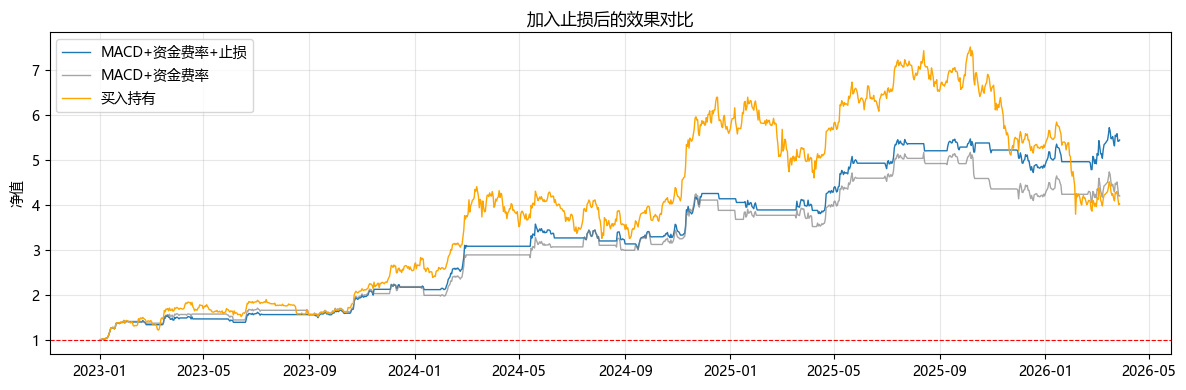

In [42]:
# 加入止损的组合策略
ret = close_btc.pct_change().dropna()
sig = combined_signal.shift(1).dropna()
common2 = ret.index.intersection(sig.index)

pv2 = [1.0]
current_holding = 0
stop_loss = 0.03  # 单日止损3%

dates_list = common2.tolist()

for i, date in enumerate(dates_list):
    if i == 0:
        current_holding = sig.loc[date]
        pv2.append(pv2[-1])
        continue
    
    # 今天的收益
    daily_ret = ret.loc[date] * current_holding
    
    # 触发止损
    if daily_ret < -stop_loss:
        daily_ret = -stop_loss
        current_holding = 0  # 强制平仓
    else:
        # 明天用新信号
        current_holding = sig.loc[date]
    
    pv2.append(pv2[-1] * (1 + daily_ret))

pv2 = pd.Series(pv2[1:], index=dates_list)

total_ret2 = pv2.iloc[-1] - 1
sharpe2 = (ret[common2] * sig[common2]).mean() / (ret[common2] * sig[common2]).std() * np.sqrt(365)
dd2 = ((pv2 - pv2.cummax()) / pv2.cummax()).min()

print(f"加止损后 累计收益：{total_ret2:.2%}")
print(f"加止损后 最大回撤：{dd2:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv2.index, pv2, linewidth=1, label="MACD+资金费率+止损")
plt.plot(pv.index, pv, linewidth=1, label="MACD+资金费率", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("加入止损后的效果对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
# Walk-Forward验证：最终组合策略
# 把数据切成4段，每段用前70%找参数，后30%验证

total_days = len(close_btc)
segment = total_days // 4
results_wf2 = []

for i in range(4):
    train_start = i * segment
    train_end = train_start + int(segment * 0.7)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train_close = close_btc.iloc[train_start:train_end]
    test_close = close_btc.iloc[test_start:test_end]
    train_funding = funding_signal.iloc[train_start:train_end] if train_start < len(funding_signal) else pd.Series()
    test_funding = funding_signal.iloc[test_start:test_end] if test_start < len(funding_signal) else pd.Series()
    
    # 在训练集上找最优MACD参数
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for sp in [7, 9, 12]:
                if fast >= slow:
                    continue
                ef = train_close.ewm(span=fast, adjust=False).mean()
                es = train_close.ewm(span=slow, adjust=False).mean()
                m = ef - es
                sl = m.ewm(span=sp, adjust=False).mean()
                cross = pd.Series(0, index=train_close.index)
                cross[m > sl] = 1
                
                # 结合资金费率
                if len(train_funding) > 0:
                    common = cross.index.intersection(train_funding.index)
                    cross[common] = cross[common] * train_funding[common]
                
                ret = train_close.pct_change().dropna()
                sig = cross.shift(1).dropna()
                c = ret.index.intersection(sig.index)
                sr = ret[c] * sig[c]
                if sr.std() == 0:
                    continue
                sharpe = sr.mean() / sr.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, sp)
    
    # 用最优参数在验证集上测试
    f, s, sp = best_params
    ef = test_close.ewm(span=f, adjust=False).mean()
    es = test_close.ewm(span=s, adjust=False).mean()
    m = ef - es
    sl = m.ewm(span=sp, adjust=False).mean()
    cross = pd.Series(0, index=test_close.index)
    cross[m > sl] = 1
    
    if len(test_funding) > 0:
        common = cross.index.intersection(test_funding.index)
        cross[common] = cross[common] * test_funding[common]
    
    ret = test_close.pct_change().dropna()
    sig = cross.shift(1).dropna()
    c = ret.index.intersection(sig.index)
    sr = ret[c] * sig[c]
    sharpe_test = sr.mean() / sr.std() * np.sqrt(365) if sr.std() > 0 else 0
    total_ret = (1 + sr).cumprod().iloc[-1] - 1 if len(sr) > 0 else 0
    
    results_wf2.append({
        "段": f"第{i+1}段",
        "最优参数": best_params,
        "训练Sharpe": round(best_sharpe, 4),
        "验证Sharpe": round(sharpe_test, 4),
        "验证收益": f"{total_ret:.2%}"
    })
    print(f"第{i+1}段完成：参数{best_params}，训练{best_sharpe:.4f}，验证{sharpe_test:.4f}，收益{total_ret:.2%}")

df_wf2 = pd.DataFrame(results_wf2)
print(f"\n{df_wf2.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf2['验证Sharpe'].mean():.4f}")

C:\Users\ROG\AppData\Local\Temp\ipykernel_7020\2721136874.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00000000e+00 6.23814286e-05 6.74247619e-05 6.67966667e-05
 6.13680952e-05 5.83700000e-05 5.03600000e-05 5.15114286e-05
 5.58966667e-05 5.25309524e-05 4.78733333e-05 5.28409524e-05
 5.58523810e-05 8.03352381e-05 9.12538095e-05 1.02665714e-04
 1.09698571e-04 1.21590476e-04 1.22757619e-04 1.24110000e-04
 1.07637143e-04 1.00000000e-04 1.00000000e-04 1.00000000e-04
 1.00000000e-04 1.00000000e-04 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 7.49866667e-05 8.12585714e-05 8.12585714e-05
 8.67361905e-05 9.26347619e-05 9.81600000e-05 9.86900000e-05
 1.06271905e-

第1段完成：参数(16, 35, 9)，训练2.4448，验证-3.6352，收益-0.00%
第2段完成：参数(16, 35, 12)，训练1.8779，验证-0.9218，收益-0.00%
第3段完成：参数(20, 26, 12)，训练1.9351，验证2.3727，收益0.00%
第4段完成：参数(8, 21, 7)，训练-0.6025，验证-1.2584，收益-0.00%

  段         最优参数  训练Sharpe  验证Sharpe   验证收益
第1段  (16, 35, 9)    2.4448   -3.6352 -0.00%
第2段 (16, 35, 12)    1.8779   -0.9218 -0.00%
第3段 (20, 26, 12)    1.9351    2.3727  0.00%
第4段   (8, 21, 7)   -0.6025   -1.2584 -0.00%

验证集平均Sharpe：-0.8607


C:\Users\ROG\AppData\Local\Temp\ipykernel_7020\2721136874.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -1.96380952e-05 -1.95533333e-05 -1.29228571e-05 -1.34166667e-05
 -1.47133333e-05 -4.23761905e-06  1.56571429e-06  3.33904762e-06
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00 -3.65800000e-05
 -3.18595238e-05 -2.83304762e-05 -1.34276190e-05 -1.11761905e-06
  1.03500000e-05  1.79595238e-05  2.58100000e-05  3.93271429e-05
  4.94052381e-05  4.96366667e-05  4.45271429e-05  4.26366667e-05
  4.61428571e-05  4.89485714e-05  4.52804762e-05  4.05328571e-05
  4.42480952e-05  5.613523

In [44]:
# 修复版Walk-Forward
results_wf2 = []

for i in range(4):
    train_start = i * segment
    train_end = train_start + int(segment * 0.7)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train_close = close_btc.iloc[train_start:train_end]
    test_close = close_btc.iloc[test_start:test_end]
    
    # 找最优MACD参数（只用MACD，不结合资金费率）
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for sp in [7, 9, 12]:
                if fast >= slow:
                    continue
                ef = train_close.ewm(span=fast, adjust=False).mean()
                es = train_close.ewm(span=slow, adjust=False).mean()
                m = ef - es
                sl = m.ewm(span=sp, adjust=False).mean()
                cross = (m > sl).astype(float)
                ret = train_close.pct_change().dropna()
                sig = cross.shift(1).dropna()
                c = ret.index.intersection(sig.index)
                sr = ret[c] * sig[c]
                if sr.std() == 0:
                    continue
                sharpe = sr.mean() / sr.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, sp)
    
    # 验证集上测试
    f, s, sp = best_params
    ef = test_close.ewm(span=f, adjust=False).mean()
    es = test_close.ewm(span=s, adjust=False).mean()
    m = ef - es
    sl = m.ewm(span=sp, adjust=False).mean()
    cross = (m > sl).astype(float)
    
    # 结合资金费率
    common = cross.index.intersection(funding_signal.index)
    cross_combined = cross.copy()
    cross_combined[common] = cross[common] * funding_signal[common].astype(float)
    
    ret = test_close.pct_change().dropna()
    sig = cross_combined.shift(1).dropna()
    c = ret.index.intersection(sig.index)
    sr = ret[c] * sig[c]
    sharpe_test = sr.mean() / sr.std() * np.sqrt(365) if sr.std() > 0 else 0
    total_ret = (1 + sr).cumprod().iloc[-1] - 1 if len(sr) > 0 else 0
    
    results_wf2.append({
        "段": f"第{i+1}段",
        "最优参数": best_params,
        "训练Sharpe": round(best_sharpe, 4),
        "验证Sharpe": round(sharpe_test, 4),
        "验证收益": f"{total_ret:.2%}"
    })
    print(f"第{i+1}段：参数{best_params}，训练{best_sharpe:.4f}，验证{sharpe_test:.4f}，收益{total_ret:.2%}")

df_wf2 = pd.DataFrame(results_wf2)
print(f"\n{df_wf2.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf2['验证Sharpe'].mean():.4f}")

第1段：参数(16, 35, 9)，训练2.9959，验证-3.6352，收益-0.00%
第2段：参数(16, 35, 12)，训练2.8985，验证-0.9218，收益-0.00%
第3段：参数(20, 26, 12)，训练1.7346，验证2.3727，收益0.00%
第4段：参数(8, 21, 7)，训练0.4183，验证-1.2584，收益-0.00%

  段         最优参数  训练Sharpe  验证Sharpe   验证收益
第1段  (16, 35, 9)    2.9959   -3.6352 -0.00%
第2段 (16, 35, 12)    2.8985   -0.9218 -0.00%
第3段 (20, 26, 12)    1.7346    2.3727  0.00%
第4段   (8, 21, 7)    0.4183   -1.2584 -0.00%

验证集平均Sharpe：-0.8607


In [45]:
results_wf3 = []

for i in range(4):
    train_start = i * segment
    train_end = train_start + int(segment * 0.7)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train_close = close_btc.iloc[train_start:train_end]
    test_close = close_btc.iloc[test_start:test_end]
    
    # 训练集找最优参数
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for sp in [7, 9, 12]:
                if fast >= slow:
                    continue
                ef = train_close.ewm(span=fast, adjust=False).mean()
                es = train_close.ewm(span=slow, adjust=False).mean()
                m = ef - es
                sl = m.ewm(span=sp, adjust=False).mean()
                cross = (m > sl).astype(float)
                ret = train_close.pct_change().dropna()
                sig = cross.shift(1).dropna()
                c = ret.index.intersection(sig.index)
                sr = ret[c] * sig[c]
                if sr.std() == 0:
                    continue
                sharpe = sr.mean() / sr.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, sp)
    
    # 验证集测试
    f, s, sp = best_params
    ef = test_close.ewm(span=f, adjust=False).mean()
    es = test_close.ewm(span=s, adjust=False).mean()
    m = ef - es
    sl = m.ewm(span=sp, adjust=False).mean()
    cross = (m > sl).astype(float)
    
    ret = test_close.pct_change().dropna()
    sig = cross.shift(1).dropna()
    c = ret.index.intersection(sig.index)
    sr = ret[c] * sig[c]
    sharpe_test = sr.mean() / sr.std() * np.sqrt(365) if sr.std() > 0 else 0
    total_ret = (1 + sr).cumprod().iloc[-1] - 1 if len(sr) > 0 else 0
    
    results_wf3.append({
        "段": f"第{i+1}段",
        "最优参数": best_params,
        "训练Sharpe": round(best_sharpe, 4),
        "验证Sharpe": round(sharpe_test, 4),
        "验证收益": f"{total_ret:.2%}"
    })
    print(f"第{i+1}段：参数{best_params}，训练{best_sharpe:.4f}，验证{sharpe_test:.4f}，收益{total_ret:.2%}")

df_wf3 = pd.DataFrame(results_wf3)
print(f"\n{df_wf3.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf3['验证Sharpe'].mean():.4f}")

第1段：参数(16, 35, 9)，训练2.9959，验证-0.6459，收益-3.87%
第2段：参数(16, 35, 12)，训练2.8985，验证-0.1754，收益-2.39%
第3段：参数(20, 26, 12)，训练1.7346，验证3.2182，收益23.64%
第4段：参数(8, 21, 7)，训练0.4183，验证0.0927，收益-0.52%

  段         最优参数  训练Sharpe  验证Sharpe   验证收益
第1段  (16, 35, 9)    2.9959   -0.6459 -3.87%
第2段 (16, 35, 12)    2.8985   -0.1754 -2.39%
第3段 (20, 26, 12)    1.7346    3.2182 23.64%
第4段   (8, 21, 7)    0.4183    0.0927 -0.52%

验证集平均Sharpe：0.6224


In [46]:
# 读取BTC完整数据（含成交量）
df_btc = pd.read_csv("btc_daily.csv", index_col=0, parse_dates=True)

close = df_btc["close"]
volume = df_btc["volume"]

# 因子一：量价背离
# 价格20日涨幅 vs 成交量20日变化，方向相反说明背离
price_change = close / close.shift(20) - 1
volume_change = volume / volume.shift(20) - 1

# 背离度 = 价格涨幅 - 成交量涨幅
# 正值大说明价涨量缩（看空信号），负值大说明价跌量增（恐慌抛售）
divergence = price_change - volume_change

# 因子二：成交量比率（今日成交量 / 20日均量）
volume_ratio = volume / volume.rolling(20).mean()

print(f"量价背离因子统计：")
print(f"均值：{divergence.mean():.4f}")
print(f"标准差：{divergence.std():.4f}")
print(f"\n成交量比率统计：")
print(f"均值：{volume_ratio.mean():.4f}")
print(f"标准差：{volume_ratio.std():.4f}")
print(f"大于2倍均量的比例：{(volume_ratio>2).mean():.2%}")

量价背离因子统计：
均值：-0.3953
标准差：1.6048

成交量比率统计：
均值：1.0111
标准差：0.5948
大于2倍均量的比例：5.33%


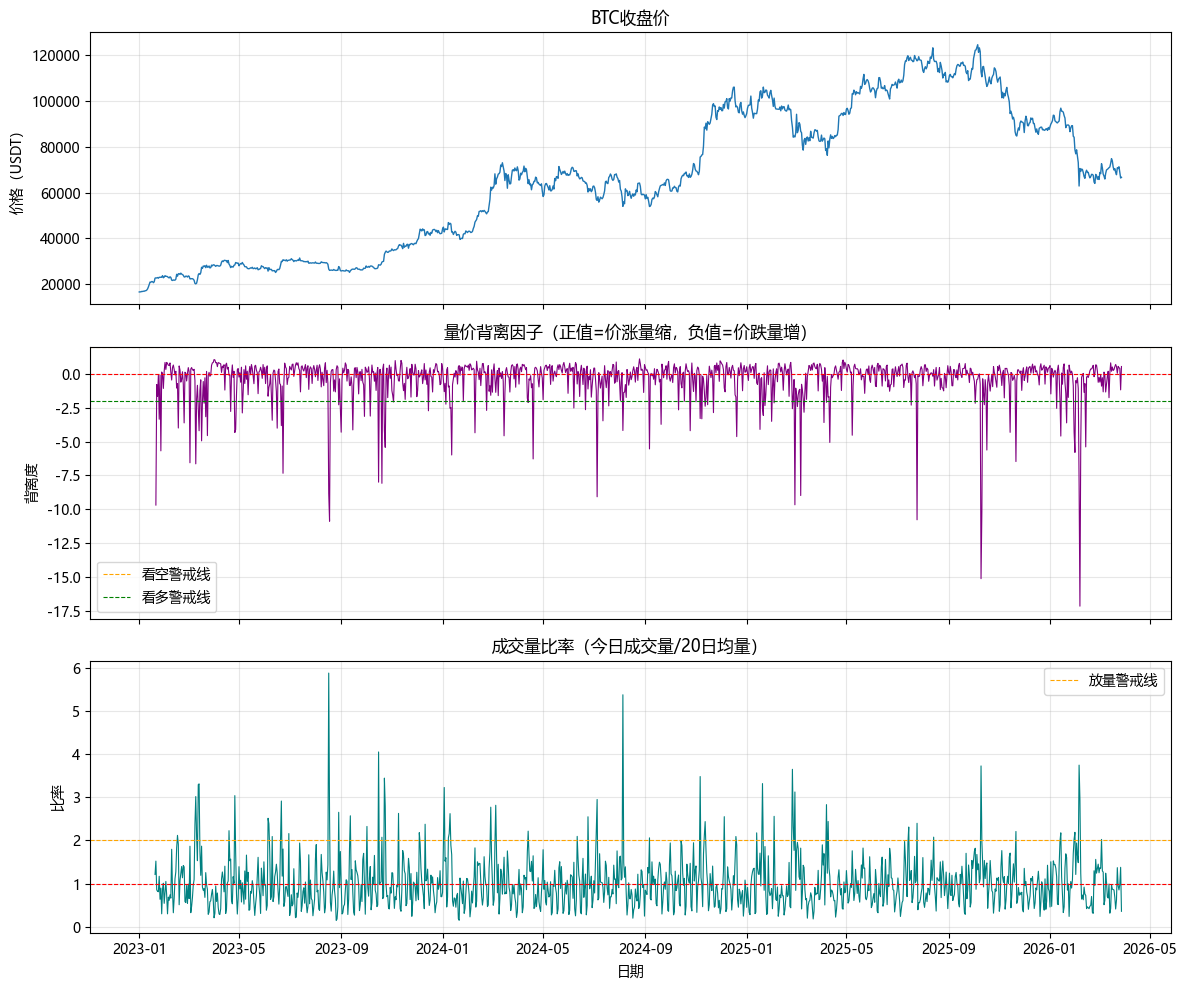

In [47]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# 上图：BTC价格
ax1.plot(close.index, close, linewidth=1)
ax1.set_title("BTC收盘价")
ax1.set_ylabel("价格（USDT）")
ax1.grid(True, alpha=0.3)

# 中图：量价背离
ax2.plot(divergence.index, divergence, linewidth=0.8, color="purple")
ax2.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax2.axhline(y=2, color="orange", linewidth=0.8, linestyle="--", label="看空警戒线")
ax2.axhline(y=-2, color="green", linewidth=0.8, linestyle="--", label="看多警戒线")
ax2.set_title("量价背离因子（正值=价涨量缩，负值=价跌量增）")
ax2.set_ylabel("背离度")
ax2.legend()
ax2.grid(True, alpha=0.3)

# 下图：成交量比率
ax3.plot(volume_ratio.index, volume_ratio, linewidth=0.8, color="teal")
ax3.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
ax3.axhline(y=2, color="orange", linewidth=0.8, linestyle="--", label="放量警戒线")
ax3.set_title("成交量比率（今日成交量/20日均量）")
ax3.set_ylabel("比率")
ax3.set_xlabel("日期")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

持仓天数比例：83.09%
成交量策略 累计收益：183.21%
成交量策略 Sharpe：0.9790
成交量策略 最大回撤：-47.03%
BTC买入持有 累计收益：301.59%


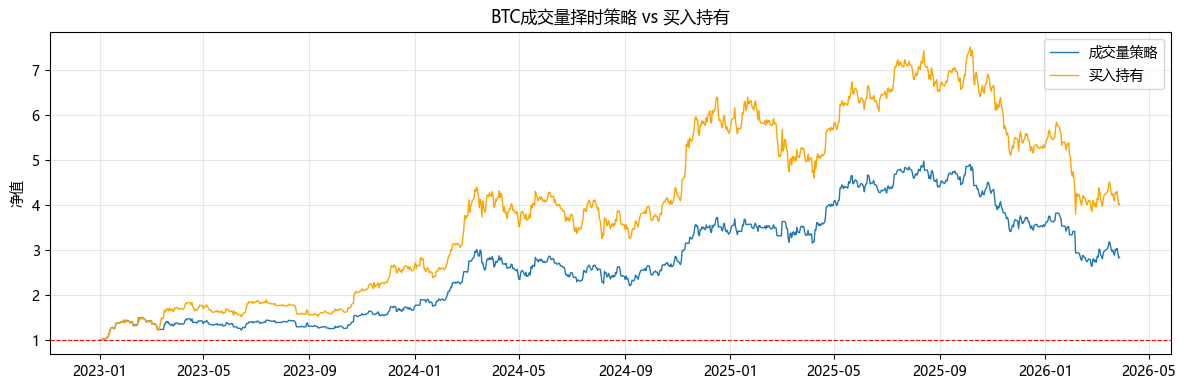

In [48]:
# 用成交量因子构建择时信号
# 逻辑：成交量比率 < 1.5（没有异常放量）且量价背离 > -3（没有恐慌抛售）才持仓

signal_volume = pd.Series(1, index=close.index)
signal_volume[volume_ratio > 1.5] = 0     # 成交量异常放大，空仓
signal_volume[divergence < -3] = 0        # 恐慌抛售，空仓

print(f"持仓天数比例：{signal_volume.mean():.2%}")

# 回测
ret = close.pct_change().dropna()
sig = signal_volume.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

pv_volume = (1 + strat_ret).cumprod()
bh = (1 + ret[common]).cumprod()

total_ret = pv_volume.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv_volume - pv_volume.cummax()) / pv_volume.cummax()).min()
bh_ret = bh.iloc[-1] - 1

print(f"成交量策略 累计收益：{total_ret:.2%}")
print(f"成交量策略 Sharpe：{sharpe:.4f}")
print(f"成交量策略 最大回撤：{dd:.2%}")
print(f"BTC买入持有 累计收益：{bh_ret:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_volume.index, pv_volume, linewidth=1, label="成交量策略")
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC成交量择时策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

四因子组合 累计收益：0.01%
四因子组合 Sharpe：1.2882
四因子组合 最大回撤：-0.01%
持仓比例：0.00%


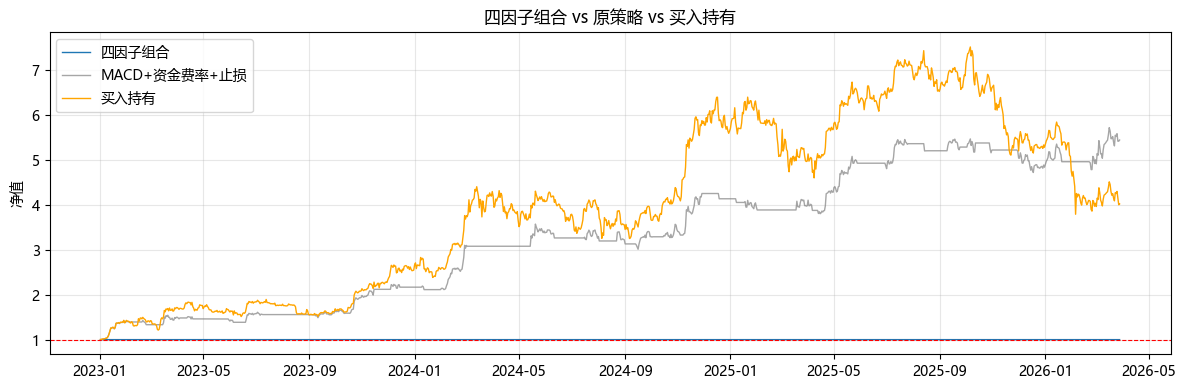

In [49]:
# 四因子组合：MACD + 资金费率 + 成交量 + 止损
ema_fast = close_btc.ewm(span=16, adjust=False).mean()
ema_slow = close_btc.ewm(span=35, adjust=False).mean()
macd_line = ema_fast - ema_slow
signal_line = macd_line.ewm(span=9, adjust=False).mean()
macd_sig = (macd_line > signal_line).astype(float)

# 对齐所有信号
common = macd_sig.index.intersection(funding_signal.index).intersection(signal_volume.index)

final_signal = macd_sig[common] * funding_signal[common].astype(float) * signal_volume[common].astype(float)

ret = close_btc.pct_change().dropna()
sig = final_signal.shift(1).dropna()
c = ret.index.intersection(sig.index)
strat_ret = ret[c] * sig[c]

# 加止损
pv_final = [1.0]
holding = 0
for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        pv_final.append(pv_final[-1])
        continue
    dr = ret.loc[date] * holding
    if dr < -0.03:
        dr = -0.03
        holding = 0
    else:
        holding = sig.loc[date]
    pv_final.append(pv_final[-1] * (1 + dr))

pv_final = pd.Series(pv_final[1:], index=c)
bh = (1 + ret[c]).cumprod()

total_ret = pv_final.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv_final - pv_final.cummax()) / pv_final.cummax()).min()

print(f"四因子组合 累计收益：{total_ret:.2%}")
print(f"四因子组合 Sharpe：{sharpe:.4f}")
print(f"四因子组合 最大回撤：{dd:.2%}")
print(f"持仓比例：{final_signal.mean():.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_final.index, pv_final, linewidth=1, label="四因子组合")
plt.plot(pv2.index, pv2, linewidth=1, label="MACD+资金费率+止损", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("四因子组合 vs 原策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
import requests

# 拉取恐贪指数历史数据（最多拉2000天）
url = "https://api.alternative.me/fng/?limit=2000&format=json"
response = requests.get(url)
data = response.json()

df_fng = pd.DataFrame(data["data"])
df_fng["date"] = pd.to_datetime(df_fng["timestamp"].astype(int), unit="s")
df_fng = df_fng.set_index("date")[["value", "value_classification"]]
df_fng["value"] = df_fng["value"].astype(int)
df_fng = df_fng.sort_index()

df_fng.to_csv("btc_fng.csv")
print(f"恐贪指数数据：{df_fng.shape}")
print(f"时间范围：{df_fng.index[0].date()} 到 {df_fng.index[-1].date()}")
print(df_fng.tail())

恐贪指数数据：(2000, 2)
时间范围：2020-10-05 到 2026-03-28
            value value_classification
date                                  
2026-03-24     11         Extreme Fear
2026-03-25     14         Extreme Fear
2026-03-26     10         Extreme Fear
2026-03-27     13         Extreme Fear
2026-03-28     12         Extreme Fear


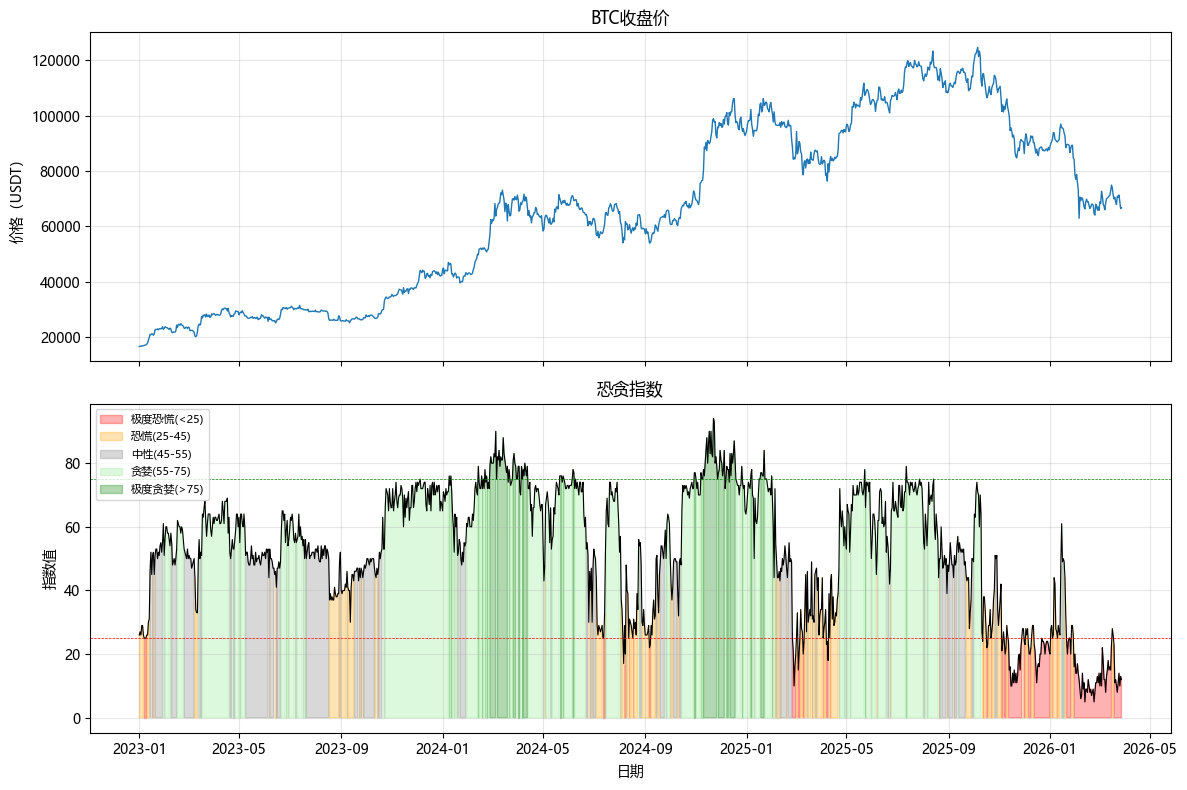

In [51]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 对齐日期
common = close_btc.index.intersection(df_fng.index)
close_aligned = close_btc[common]
fng_aligned = df_fng["value"][common]

# 上图：BTC价格
ax1.plot(close_aligned.index, close_aligned, linewidth=1)
ax1.set_title("BTC收盘价")
ax1.set_ylabel("价格（USDT）")
ax1.grid(True, alpha=0.3)

# 下图：恐贪指数，用颜色区分区间
ax2.fill_between(fng_aligned.index, fng_aligned, 
                  where=fng_aligned<=25, color="red", alpha=0.3, label="极度恐慌(<25)")
ax2.fill_between(fng_aligned.index, fng_aligned,
                  where=(fng_aligned>25)&(fng_aligned<=45), color="orange", alpha=0.3, label="恐慌(25-45)")
ax2.fill_between(fng_aligned.index, fng_aligned,
                  where=(fng_aligned>45)&(fng_aligned<=55), color="gray", alpha=0.3, label="中性(45-55)")
ax2.fill_between(fng_aligned.index, fng_aligned,
                  where=(fng_aligned>55)&(fng_aligned<=75), color="lightgreen", alpha=0.3, label="贪婪(55-75)")
ax2.fill_between(fng_aligned.index, fng_aligned,
                  where=fng_aligned>75, color="green", alpha=0.3, label="极度贪婪(>75)")
ax2.plot(fng_aligned.index, fng_aligned, linewidth=0.8, color="black")
ax2.axhline(y=25, color="red", linewidth=0.5, linestyle="--")
ax2.axhline(y=75, color="green", linewidth=0.5, linestyle="--")
ax2.set_title("恐贪指数")
ax2.set_ylabel("指数值")
ax2.set_xlabel("日期")
ax2.legend(loc="upper left", fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

持仓天数比例：59.39%
极度恐慌天数：142天
极度贪婪天数：120天

恐贪策略 累计收益：132.78%
恐贪策略 Sharpe：0.8827
恐贪策略 最大回撤：-47.42%
买入持有 累计收益：301.59%


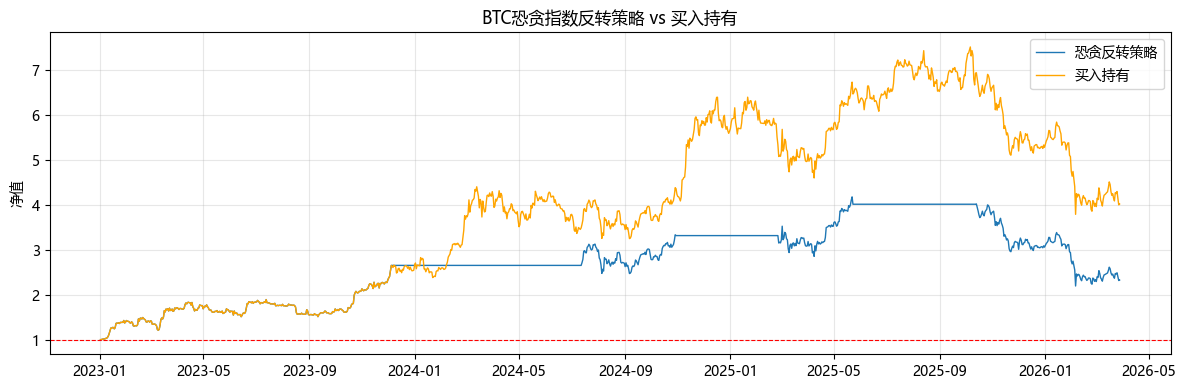

In [52]:
# 恐贪指数反转策略
# 极度恐慌(<25)买入，极度贪婪(>75)卖出，中间保持不变

signal_fng = pd.Series(np.nan, index=fng_aligned.index)
signal_fng[fng_aligned <= 25] = 1   # 极度恐慌，买入
signal_fng[fng_aligned >= 75] = 0   # 极度贪婪，卖出
signal_fng = signal_fng.ffill().fillna(1)  # 其他时间保持上一个状态

print(f"持仓天数比例：{signal_fng.mean():.2%}")
print(f"极度恐慌天数：{(fng_aligned<=25).sum()}天")
print(f"极度贪婪天数：{(fng_aligned>=75).sum()}天")

ret = close_aligned.pct_change().dropna()
sig = signal_fng.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

pv_fng = (1 + strat_ret).cumprod()
bh = (1 + ret[common]).cumprod()

total_ret = pv_fng.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv_fng - pv_fng.cummax()) / pv_fng.cummax()).min()

print(f"\n恐贪策略 累计收益：{total_ret:.2%}")
print(f"恐贪策略 Sharpe：{sharpe:.4f}")
print(f"恐贪策略 最大回撤：{dd:.2%}")
print(f"买入持有 累计收益：{bh.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_fng.index, pv_fng, linewidth=1, label="恐贪反转策略")
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC恐贪指数反转策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

顺势策略 持仓比例：71.91%
顺势策略 累计收益：139.70%
顺势策略 Sharpe：0.9047
顺势策略 最大回撤：-41.21%


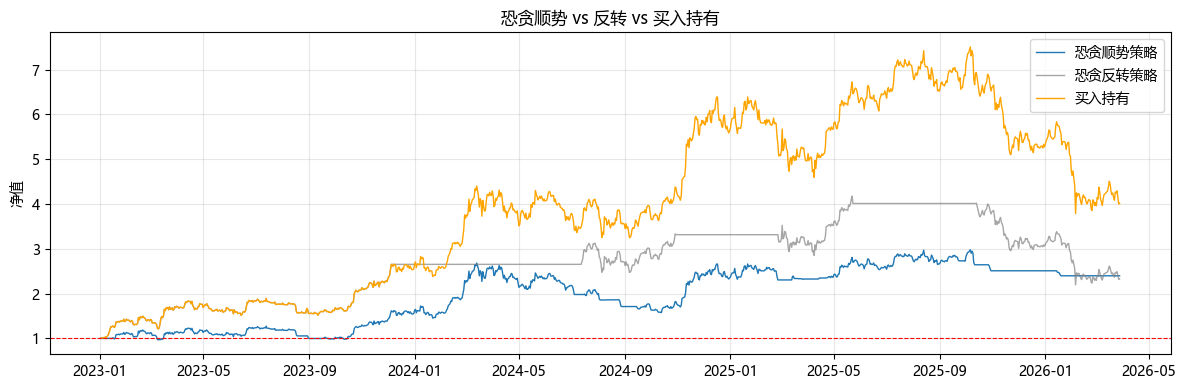

In [53]:
# 顺势策略：贪婪持仓，恐慌空仓
signal_fng2 = pd.Series(0, index=fng_aligned.index)
signal_fng2[fng_aligned >= 45] = 1  # 中性以上才持仓

ret = close_aligned.pct_change().dropna()
sig = signal_fng2.shift(1).dropna()
common = ret.index.intersection(sig.index)
strat_ret = ret[common] * sig[common]

pv_fng2 = (1 + strat_ret).cumprod()
bh = (1 + ret[common]).cumprod()

total_ret = pv_fng2.iloc[-1] - 1
sharpe = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd = ((pv_fng2 - pv_fng2.cummax()) / pv_fng2.cummax()).min()

print(f"顺势策略 持仓比例：{signal_fng2.mean():.2%}")
print(f"顺势策略 累计收益：{total_ret:.2%}")
print(f"顺势策略 Sharpe：{sharpe:.4f}")
print(f"顺势策略 最大回撤：{dd:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_fng2.index, pv_fng2, linewidth=1, label="恐贪顺势策略")
plt.plot(pv_fng.index, pv_fng, linewidth=1, label="恐贪反转策略", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("恐贪顺势 vs 反转 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MACD+资金费率+恐贪+止损 累计收益：0.01%
MACD+资金费率+恐贪+止损 Sharpe：1.5317
MACD+资金费率+恐贪+止损 最大回撤：-0.00%
持仓比例：0.00%


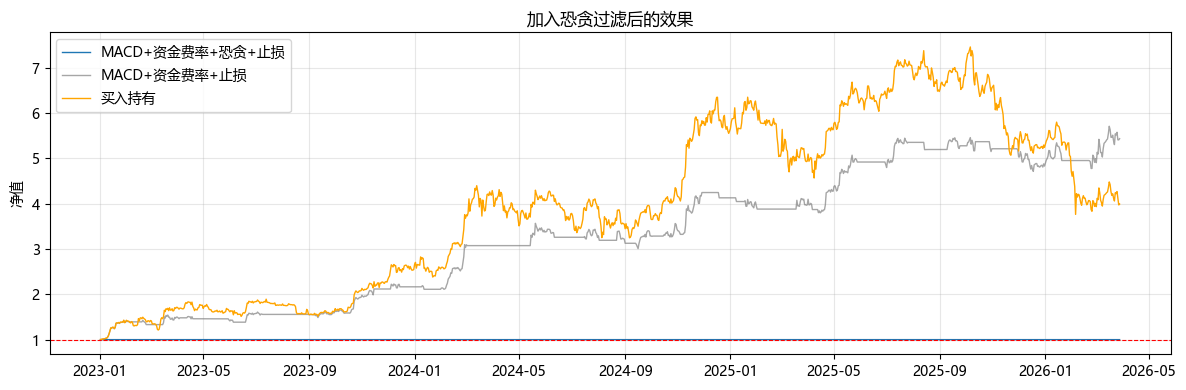

In [54]:
# MACD + 资金费率 + 恐贪过滤 + 止损
signal_fng3 = pd.Series(1, index=fng_aligned.index)
signal_fng3[fng_aligned >= 80] = 0  # 极度贪婪时空仓

common = macd_sig.index.intersection(funding_signal.index).intersection(signal_fng3.index)
final_signal2 = macd_sig[common] * funding_signal[common].astype(float) * signal_fng3[common].astype(float)

ret = close_btc.pct_change().dropna()
sig = final_signal2.shift(1).dropna()
c = ret.index.intersection(sig.index)
strat_ret = ret[c] * sig[c]

pv_final2 = [1.0]
holding = 0
for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        pv_final2.append(pv_final2[-1])
        continue
    dr = ret.loc[date] * holding
    if dr < -0.03:
        dr = -0.03
        holding = 0
    else:
        holding = sig.loc[date]
    pv_final2.append(pv_final2[-1] * (1 + dr))

pv_final2 = pd.Series(pv_final2[1:], index=c)
bh = (1 + ret[c]).cumprod()

total_ret2 = pv_final2.iloc[-1] - 1
sharpe2 = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd2 = ((pv_final2 - pv_final2.cummax()) / pv_final2.cummax()).min()

print(f"MACD+资金费率+恐贪+止损 累计收益：{total_ret2:.2%}")
print(f"MACD+资金费率+恐贪+止损 Sharpe：{sharpe2:.4f}")
print(f"MACD+资金费率+恐贪+止损 最大回撤：{dd2:.2%}")
print(f"持仓比例：{final_signal2.mean():.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_final2.index, pv_final2, linewidth=1, label="MACD+资金费率+恐贪+止损")
plt.plot(pv2.index, pv2, linewidth=1, label="MACD+资金费率+止损", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("加入恐贪过滤后的效果")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
# 独立叠加：每个信号单独计算，然后用平均值决定仓位
# 三个信号各自对齐到BTC的日期索引

btc_dates = close_btc.index

# MACD信号（已有）
s1 = macd_sig.reindex(btc_dates).fillna(0)

# 资金费率信号（已有）
s2 = funding_signal.reindex(btc_dates).fillna(1)

# 恐贪信号
fng_reindexed = df_fng["value"].reindex(btc_dates, method="ffill").fillna(50)
s3 = (fng_reindexed < 80).astype(float)

# 三个信号都是1才持仓
combined = (s1 * s2 * s3)

print(f"MACD持仓比例：{s1.mean():.2%}")
print(f"资金费率持仓比例：{s2.mean():.2%}")
print(f"恐贪持仓比例：{s3.mean():.2%}")
print(f"三者组合持仓比例：{combined.mean():.2%}")

MACD持仓比例：48.10%
资金费率持仓比例：0.01%
恐贪持仓比例：96.20%
三者组合持仓比例：0.00%


MACD+恐贪+止损 持仓比例：45.48%
MACD+恐贪+止损 累计收益：423.22%
MACD+恐贪+止损 Sharpe：1.7001
MACD+恐贪+止损 最大回撤：-15.66%


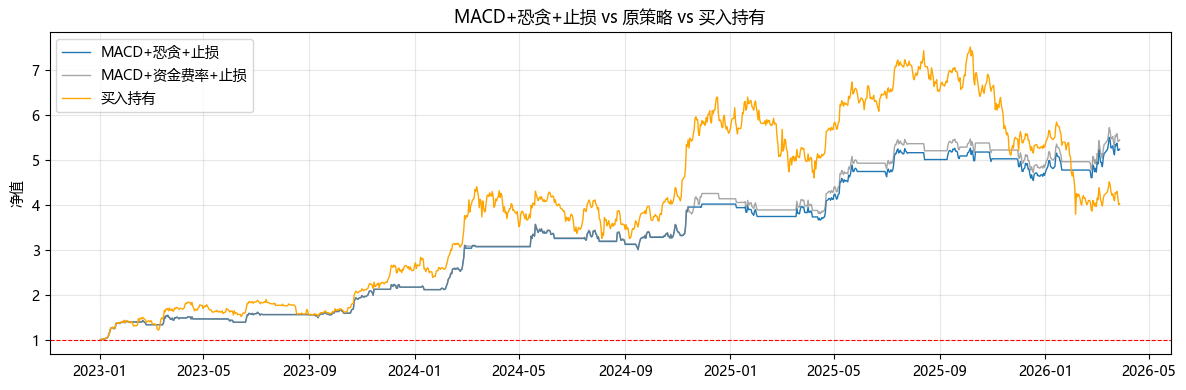

In [56]:
# 只组合MACD + 恐贪
combined2 = s1 * s3

ret = close_btc.pct_change().dropna()
sig = combined2.shift(1).dropna()
c = ret.index.intersection(sig.index)
strat_ret = ret[c] * sig[c]

# 加止损
pv3 = [1.0]
holding = 0
for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        pv3.append(pv3[-1])
        continue
    dr = ret.loc[date] * holding
    if dr < -0.03:
        dr = -0.03
        holding = 0
    else:
        holding = sig.loc[date]
    pv3.append(pv3[-1] * (1 + dr))

pv3 = pd.Series(pv3[1:], index=c)
bh = (1 + ret[c]).cumprod()

total_ret3 = pv3.iloc[-1] - 1
sharpe3 = strat_ret.mean() / strat_ret.std() * np.sqrt(365)
dd3 = ((pv3 - pv3.cummax()) / pv3.cummax()).min()

print(f"MACD+恐贪+止损 持仓比例：{combined2.mean():.2%}")
print(f"MACD+恐贪+止损 累计收益：{total_ret3:.2%}")
print(f"MACD+恐贪+止损 Sharpe：{sharpe3:.4f}")
print(f"MACD+恐贪+止损 最大回撤：{dd3:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv3.index, pv3, linewidth=1, label="MACD+恐贪+止损")
plt.plot(pv2.index, pv2, linewidth=1, label="MACD+资金费率+止损", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=1, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("MACD+恐贪+止损 vs 原策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
# 测试不同止损阈值
for stop in [0.01, 0.02, 0.03, 0.05, 0.08, 0.10, 999]:
    pv_test = [1.0]
    holding = 0
    
    for i, date in enumerate(c):
        if i == 0:
            holding = sig.loc[date]
            pv_test.append(pv_test[-1])
            continue
        dr = ret.loc[date] * holding
        if dr < -stop:
            dr = -stop
            holding = 0
        else:
            holding = sig.loc[date]
        pv_test.append(pv_test[-1] * (1 + dr))
    
    pv_test = pd.Series(pv_test[1:], index=c)
    total = pv_test.iloc[-1] - 1
    sr = (ret[c] * sig[c])
    sharpe = sr.mean() / sr.std() * np.sqrt(365)
    dd = ((pv_test - pv_test.cummax()) / pv_test.cummax()).min()
    label = f"{stop*100:.0f}%" if stop != 999 else "无止损"
    print(f"止损{label:>6}：累计{total:.2%}  Sharpe {sharpe:.4f}  回撤{dd:.2%}")

止损    1%：累计1335.98%  Sharpe 1.7001  回撤-5.00%
止损    2%：累计612.25%  Sharpe 1.7001  回撤-9.44%
止损    3%：累计423.22%  Sharpe 1.7001  回撤-15.66%
止损    5%：累计295.78%  Sharpe 1.7001  回撤-19.28%
止损    8%：累计274.53%  Sharpe 1.7001  回撤-21.92%
止损   10%：累计274.53%  Sharpe 1.7001  回撤-21.92%
止损   无止损：累计274.53%  Sharpe 1.7001  回撤-21.92%


In [58]:
# 统计1%止损触发次数
stop_count = 0
holding = 0

for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        continue
    dr = ret.loc[date] * holding
    if dr < -0.01:
        stop_count += 1
        holding = 0
    else:
        holding = sig.loc[date]

print(f"总天数：{len(c)}")
print(f"1%止损触发次数：{stop_count}")
print(f"平均每年触发：{stop_count/(len(c)/365):.0f}次")
print(f"每次触发成本约0.1%，总成本：{stop_count*0.001:.2%}")

总天数：1182
1%止损触发次数：104
平均每年触发：32次
每次触发成本约0.1%，总成本：10.40%


In [59]:
# Walk-Forward验证：MACD+恐贪+止损
total_days = len(close_btc)
segment = total_days // 4
results_wf_final = []

for i in range(4):
    train_start = i * segment
    train_end = train_start + int(segment * 0.7)
    test_start = train_end
    test_end = min(train_start + segment, total_days)
    
    train_close = close_btc.iloc[train_start:train_end]
    test_close = close_btc.iloc[test_start:test_end]
    
    # 训练集找最优MACD参数
    best_sharpe = -999
    best_params = None
    
    for fast in [8, 12, 16, 20]:
        for slow in [21, 26, 30, 35]:
            for sp in [7, 9, 12]:
                if fast >= slow:
                    continue
                ef = train_close.ewm(span=fast, adjust=False).mean()
                es = train_close.ewm(span=slow, adjust=False).mean()
                m = ef - es
                sl = m.ewm(span=sp, adjust=False).mean()
                cross = (m > sl).astype(float)
                
                # 加恐贪过滤
                fng_train = fng_reindexed[train_close.index]
                fng_sig = (fng_train < 80).astype(float)
                combined = cross * fng_sig
                
                ret = train_close.pct_change().dropna()
                sig = combined.shift(1).dropna()
                c2 = ret.index.intersection(sig.index)
                sr = ret[c2] * sig[c2]
                if sr.std() == 0:
                    continue
                sharpe = sr.mean() / sr.std() * np.sqrt(365)
                if sharpe > best_sharpe:
                    best_sharpe = sharpe
                    best_params = (fast, slow, sp)
    
    # 验证集测试
    f, s, sp = best_params
    ef = test_close.ewm(span=f, adjust=False).mean()
    es = test_close.ewm(span=s, adjust=False).mean()
    m = ef - es
    sl = m.ewm(span=sp, adjust=False).mean()
    cross = (m > sl).astype(float)
    
    fng_test = fng_reindexed[test_close.index]
    fng_sig = (fng_test < 80).astype(float)
    combined = cross * fng_sig
    
    ret = test_close.pct_change().dropna()
    sig = combined.shift(1).dropna()
    c2 = ret.index.intersection(sig.index)
    
    # 加止损
    pv_wf = [1.0]
    holding = 0
    for j, date in enumerate(c2):
        if j == 0:
            holding = sig.loc[date]
            pv_wf.append(pv_wf[-1])
            continue
        dr = ret.loc[date] * holding
        if dr < -0.03:
            dr = -0.03
            holding = 0
        else:
            holding = sig.loc[date]
        pv_wf.append(pv_wf[-1] * (1 + dr))
    
    pv_wf = pd.Series(pv_wf[1:], index=c2)
    sr = ret[c2] * sig[c2]
    sharpe_test = sr.mean() / sr.std() * np.sqrt(365) if sr.std() > 0 else 0
    total_ret = pv_wf.iloc[-1] - 1 if len(pv_wf) > 0 else 0
    
    results_wf_final.append({
        "段": f"第{i+1}段",
        "最优参数": best_params,
        "训练Sharpe": round(best_sharpe, 4),
        "验证Sharpe": round(sharpe_test, 4),
        "验证收益": f"{total_ret:.2%}"
    })
    print(f"第{i+1}段：参数{best_params}，训练{best_sharpe:.4f}，验证{sharpe_test:.4f}，收益{total_ret:.2%}")

df_wf_final = pd.DataFrame(results_wf_final)
print(f"\n{df_wf_final.to_string(index=False)}")
print(f"\n验证集平均Sharpe：{df_wf_final['验证Sharpe'].mean():.4f}")

第1段：参数(16, 35, 9)，训练2.9959，验证-0.6459，收益2.64%
第2段：参数(16, 35, 12)，训练3.1526，验证-0.1754，收益-5.90%
第3段：参数(20, 26, 12)，训练1.5819，验证3.2182，收益32.62%
第4段：参数(8, 21, 7)，训练0.4183，验证0.0927，收益2.14%

  段         最优参数  训练Sharpe  验证Sharpe   验证收益
第1段  (16, 35, 9)    2.9959   -0.6459  2.64%
第2段 (16, 35, 12)    3.1526   -0.1754 -5.90%
第3段 (20, 26, 12)    1.5819    3.2182 32.62%
第4段   (8, 21, 7)    0.4183    0.0927  2.14%

验证集平均Sharpe：0.6224


In [67]:
import requests

url = "https://community-api.coinmetrics.io/v4/timeseries/asset-metrics"
params = {
    "assets": "btc",
    "metrics": "CapMrktCurUSD,CapRealUSD",
    "start_time": "2020-01-01",
    "page_size": 2000
}

response = requests.get(url, params=params)
print(response.status_code)
print(response.json().keys())

403
dict_keys(['error'])


In [68]:
print(response.json())

{'error': {'type': 'forbidden', 'message': "Requested metric 'CapRealUSD' with frequency '1d' for asset 'btc' is not available with supplied credentials."}}


In [69]:
# 先看看免费能拿到哪些指标
params = {
    "assets": "btc",
    "metrics": "CapMrktCurUSD",
    "start_time": "2020-01-01",
    "page_size": 2000
}

response = requests.get(url, params=params)
data = response.json()
print(response.status_code)
print(data.keys())
if "data" in data:
    df_cm = pd.DataFrame(data["data"])
    print(df_cm.head())

200
dict_keys(['data', 'next_page_token', 'next_page_url'])
  asset                            time                    CapMrktCurUSD
0   btc  2020-10-05T00:00:00.000000000Z  199389146257.067778859999565925
1   btc  2020-10-06T00:00:00.000000000Z  196135347147.171177705755523975
2   btc  2020-10-07T00:00:00.000000000Z  197456284574.175958742105977875
3   btc  2020-10-08T00:00:00.000000000Z   201823517432.12747387289661555
4   btc  2020-10-09T00:00:00.000000000Z  205009453844.920920512990838675


In [70]:
params = {
    "assets": "btc",
    "metrics": "AdrActCnt",
    "start_time": "2020-01-01",
    "page_size": 2000
}

response = requests.get(url, params=params)
data = response.json()
print(response.status_code)
if "data" in data:
    df_addr = pd.DataFrame(data["data"])
    df_addr["date"] = pd.to_datetime(df_addr["time"])
    df_addr = df_addr.set_index("date")["AdrActCnt"].astype(float)
    df_addr.to_csv("btc_active_addr.csv")
    print(f"活跃地址数据：{df_addr.shape}")
    print(df_addr.tail())
else:
    print(data)

200
活跃地址数据：(2000,)
date
2026-03-23 00:00:00+00:00    640101.0
2026-03-24 00:00:00+00:00    587472.0
2026-03-25 00:00:00+00:00    657017.0
2026-03-26 00:00:00+00:00    623105.0
2026-03-27 00:00:00+00:00    640242.0
Name: AdrActCnt, dtype: float64


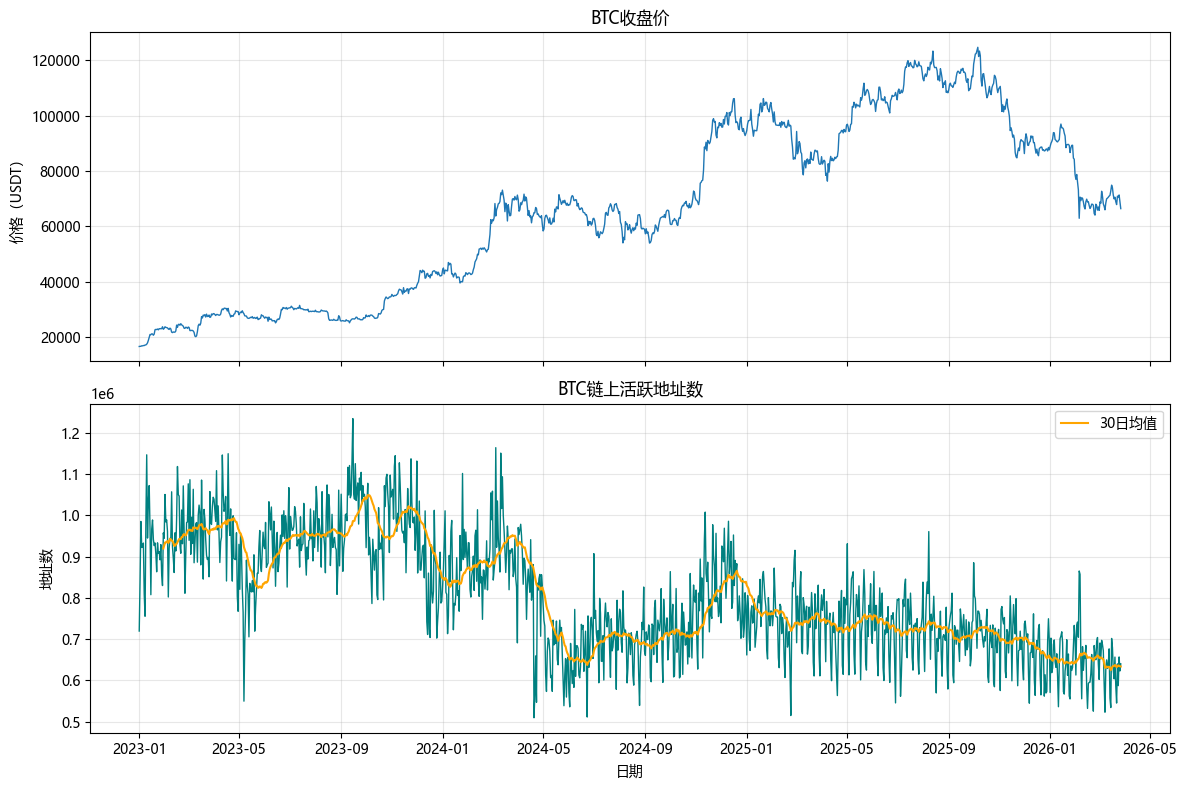

活跃地址均值：802675
活跃地址最大值：1234300
活跃地址最小值：509709


In [71]:
# 对齐日期
df_addr.index = df_addr.index.tz_localize(None)
common = close_btc.index.intersection(df_addr.index)
close_aligned2 = close_btc[common]
addr_aligned = df_addr[common]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(close_aligned2.index, close_aligned2, linewidth=1)
ax1.set_title("BTC收盘价")
ax1.set_ylabel("价格（USDT）")
ax1.grid(True, alpha=0.3)

ax2.plot(addr_aligned.index, addr_aligned, linewidth=1, color="teal")
ax2.plot(addr_aligned.index, addr_aligned.rolling(30).mean(), 
         linewidth=1.5, color="orange", label="30日均值")
ax2.set_title("BTC链上活跃地址数")
ax2.set_ylabel("地址数")
ax2.set_xlabel("日期")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"活跃地址均值：{addr_aligned.mean():.0f}")
print(f"活跃地址最大值：{addr_aligned.max():.0f}")
print(f"活跃地址最小值：{addr_aligned.min():.0f}")

活跃地址变化率 IC值：-0.0119


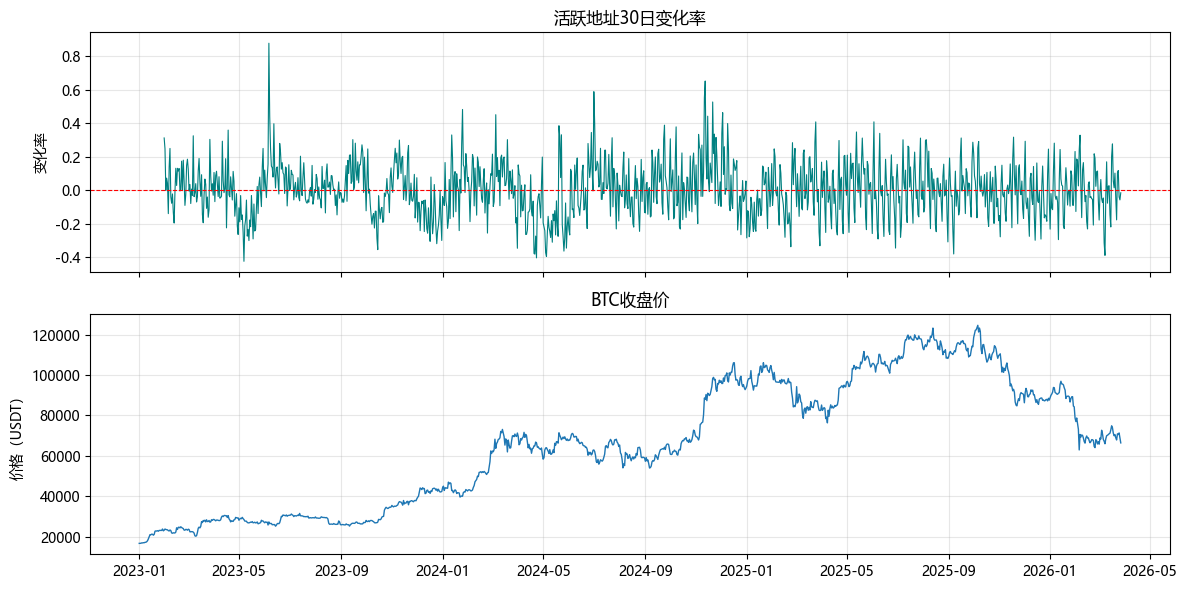

In [72]:
# 活跃地址30日变化率作为因子
addr_change = addr_aligned / addr_aligned.shift(30) - 1

# 做IC检验
future_ret = close_aligned2.shift(-10) / close_aligned2 - 1
ic = addr_change.corr(future_ret, method="spearman")
print(f"活跃地址变化率 IC值：{ic:.4f}")

# 画因子和未来收益的关系
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

ax1.plot(addr_change.index, addr_change, linewidth=0.8, color="teal")
ax1.axhline(y=0, color="red", linewidth=0.8, linestyle="--")
ax1.set_title("活跃地址30日变化率")
ax1.set_ylabel("变化率")
ax1.grid(True, alpha=0.3)

ax2.plot(close_aligned2.index, close_aligned2, linewidth=1)
ax2.set_title("BTC收盘价")
ax2.set_ylabel("价格（USDT）")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [76]:
# 拉取BTC/USDT小时线数据
exchange = ccxt.binance({
    'proxies': {
        'http': 'http://127.0.0.1:7897',
        'https': 'http://127.0.0.1:7897',
    },
    'options': {
        'defaultType': 'future'
    }
})
ohlcv_1h = []
since = exchange.parse8601("2023-01-01T00:00:00Z")

while True:
    batch = exchange.fetch_ohlcv("BTC/USDT", timeframe="1h", since=since, limit=300)
    if not batch:
        break
    ohlcv_1h += batch
    since = batch[-1][0] + 3600000
    if batch[-1][0] >= exchange.milliseconds():
        break
    time.sleep(0.3)

df_1h = pd.DataFrame(ohlcv_1h, columns=["timestamp","open","high","low","close","volume"])
df_1h["date"] = pd.to_datetime(df_1h["timestamp"], unit="ms")
df_1h = df_1h.set_index("date")
df_1h = df_1h.drop(columns=["timestamp"])
df_1h = df_1h[~df_1h.index.duplicated()]
df_1h.to_csv("btc_1h.csv")

print(f"数据维度：{df_1h.shape}")
print(f"时间范围：{df_1h.index[0].date()} 到 {df_1h.index[-1].date()}")

数据维度：(28385, 5)
时间范围：2023-01-01 到 2026-03-28


小时线MACD 累计收益：172.36%
小时线MACD 年化收益：36.24%
小时线MACD Sharpe：1.1000
小时线MACD 最大回撤：-36.26%
买入持有 累计收益：305.47%


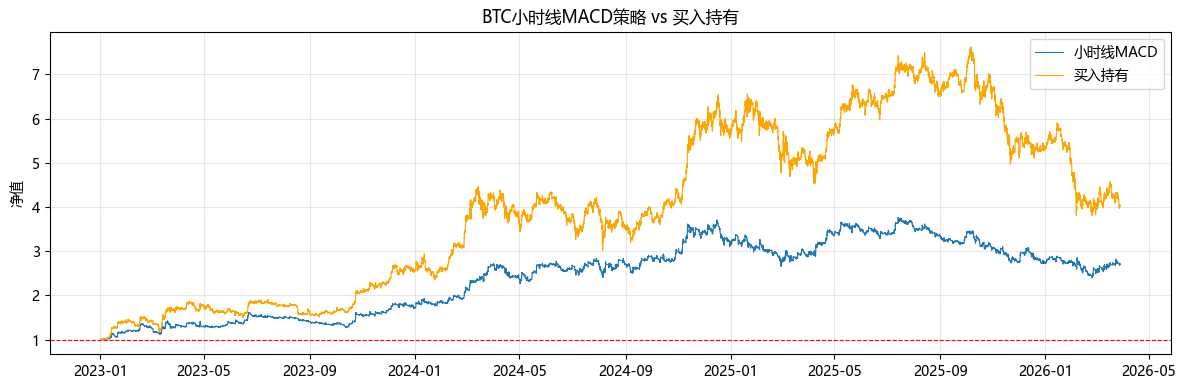

In [77]:
close_1h = df_1h["close"]

# 计算小时线MACD
ema_fast = close_1h.ewm(span=16, adjust=False).mean()
ema_slow = close_1h.ewm(span=35, adjust=False).mean()
macd_1h = ema_fast - ema_slow
signal_1h = macd_1h.ewm(span=9, adjust=False).mean()

cross_1h = (macd_1h > signal_1h).astype(float)

# 回测
ret_1h = close_1h.pct_change().dropna()
sig_1h = cross_1h.shift(1).dropna()
common = ret_1h.index.intersection(sig_1h.index)
strat_ret_1h = ret_1h[common] * sig_1h[common]

pv_1h = (1 + strat_ret_1h).cumprod()
bh_1h = (1 + ret_1h[common]).cumprod()

total_ret = pv_1h.iloc[-1] - 1
annual_ret = (1 + total_ret) ** (8760/len(pv_1h)) - 1
sharpe = strat_ret_1h.mean() / strat_ret_1h.std() * np.sqrt(8760)
dd = ((pv_1h - pv_1h.cummax()) / pv_1h.cummax()).min()

print(f"小时线MACD 累计收益：{total_ret:.2%}")
print(f"小时线MACD 年化收益：{annual_ret:.2%}")
print(f"小时线MACD Sharpe：{sharpe:.4f}")
print(f"小时线MACD 最大回撤：{dd:.2%}")
print(f"买入持有 累计收益：{bh_1h.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_1h.index, pv_1h, linewidth=0.8, label="小时线MACD")
plt.plot(bh_1h.index, bh_1h, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC小时线MACD策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
# 小时线参数优化
results_1h = []

for fast in [20, 50, 100, 200]:
    for slow in [50, 100, 200, 300]:
        for sp in [9, 20, 50]:
            if fast >= slow:
                continue
            ef = close_1h.ewm(span=fast, adjust=False).mean()
            es = close_1h.ewm(span=slow, adjust=False).mean()
            m = ef - es
            sl = m.ewm(span=sp, adjust=False).mean()
            cross = (m > sl).astype(float)
            ret = close_1h.pct_change().dropna()
            sig = cross.shift(1).dropna()
            c = ret.index.intersection(sig.index)
            sr = ret[c] * sig[c]
            if sr.std() == 0:
                continue
            sharpe = sr.mean() / sr.std() * np.sqrt(8760)
            total = (1 + sr).cumprod().iloc[-1] - 1
            dd = ((( 1 + sr).cumprod() - (1 + sr).cumprod().cummax()) / (1 + sr).cumprod().cummax()).min()
            results_1h.append({
                "fast": fast, "slow": slow, "signal": sp,
                "累计收益": total, "Sharpe": sharpe, "最大回撤": dd
            })

df_1h_results = pd.DataFrame(results_1h).sort_values("Sharpe", ascending=False)
print(df_1h_results.head(10).to_string(index=False))

 fast  slow  signal     累计收益   Sharpe      最大回撤
  100   200      50 3.454887 1.569474 -0.365180
  200   300      20 3.331152 1.557807 -0.260542
  100   300      50 3.191380 1.525889 -0.309552
  200   300      50 2.890539 1.452128 -0.291341
   20   200      20 2.528168 1.354342 -0.327609
   20   200       9 2.255937 1.271381 -0.349127
  100   300      20 2.184053 1.258246 -0.350904
   50   300      50 2.212616 1.258130 -0.387205
   20   300       9 2.218423 1.257884 -0.345956
   20    50      20 2.181661 1.256673 -0.340772


小时线最优 累计收益：345.49%
小时线最优 Sharpe：1.5695
小时线最优 最大回撤：-36.52%


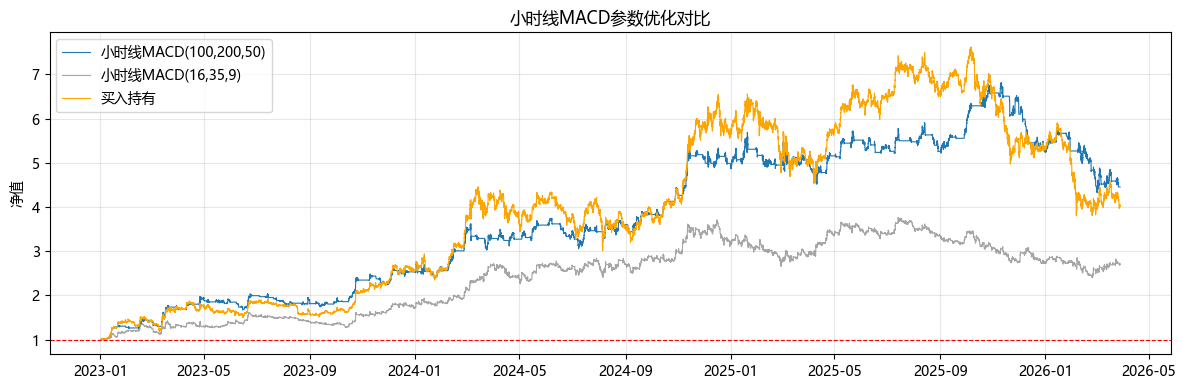

In [79]:
# 用最优参数重新跑
ef = close_1h.ewm(span=100, adjust=False).mean()
es = close_1h.ewm(span=200, adjust=False).mean()
m = ef - es
sl = m.ewm(span=50, adjust=False).mean()
cross_best = (m > sl).astype(float)

ret = close_1h.pct_change().dropna()
sig = cross_best.shift(1).dropna()
c = ret.index.intersection(sig.index)
sr = ret[c] * sig[c]

pv_1h_best = (1 + sr).cumprod()
bh = (1 + ret[c]).cumprod()

dd = ((pv_1h_best - pv_1h_best.cummax()) / pv_1h_best.cummax()).min()
sharpe = sr.mean() / sr.std() * np.sqrt(8760)
total = pv_1h_best.iloc[-1] - 1

print(f"小时线最优 累计收益：{total:.2%}")
print(f"小时线最优 Sharpe：{sharpe:.4f}")
print(f"小时线最优 最大回撤：{dd:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_1h_best.index, pv_1h_best, linewidth=0.8, label="小时线MACD(100,200,50)")
plt.plot(pv_1h.index, pv_1h, linewidth=0.8, label="小时线MACD(16,35,9)", color="gray", alpha=0.7)
plt.plot(bh.index, bh, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("小时线MACD参数优化对比")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [80]:
# 小时线最优MACD + 止损
ret = close_1h.pct_change().dropna()
sig = cross_best.shift(1).dropna()
c = ret.index.intersection(sig.index)

# 测试不同止损阈值
for stop in [0.02, 0.03, 0.05, 0.08]:
    pv_test = [1.0]
    holding = 0
    for i, date in enumerate(c):
        if i == 0:
            holding = sig.loc[date]
            pv_test.append(pv_test[-1])
            continue
        dr = ret.loc[date] * holding
        if dr < -stop:
            dr = -stop
            holding = 0
        else:
            holding = sig.loc[date]
        pv_test.append(pv_test[-1] * (1 + dr))
    
    pv_test = pd.Series(pv_test[1:], index=c)
    total = pv_test.iloc[-1] - 1
    sr = ret[c] * sig[c]
    sharpe = sr.mean() / sr.std() * np.sqrt(8760)
    dd = ((pv_test - pv_test.cummax()) / pv_test.cummax()).min()
    print(f"止损{stop*100:.0f}%：累计{total:.2%}  Sharpe {sharpe:.4f}  回撤{dd:.2%}")

止损2%：累计602.63%  Sharpe 1.5695  回撤-32.79%
止损3%：累计397.96%  Sharpe 1.5695  回撤-35.86%
止损5%：累计355.43%  Sharpe 1.5695  回撤-35.97%
止损8%：累计360.04%  Sharpe 1.5695  回撤-35.97%


In [81]:
# 加2%止损之后重新优化参数
results_1h_v2 = []

for fast in [50, 100, 150, 200]:
    for slow in [100, 200, 300, 400]:
        for sp in [20, 50, 100]:
            if fast >= slow:
                continue
            ef = close_1h.ewm(span=fast, adjust=False).mean()
            es = close_1h.ewm(span=slow, adjust=False).mean()
            m = ef - es
            sl = m.ewm(span=sp, adjust=False).mean()
            cross = (m > sl).astype(float)
            
            ret = close_1h.pct_change().dropna()
            sig = cross.shift(1).dropna()
            c = ret.index.intersection(sig.index)
            
            # 加2%止损
            pv = [1.0]
            holding = 0
            for i, date in enumerate(c):
                if i == 0:
                    holding = sig.loc[date]
                    pv.append(pv[-1])
                    continue
                dr = ret.loc[date] * holding
                if dr < -0.02:
                    dr = -0.02
                    holding = 0
                else:
                    holding = sig.loc[date]
                pv.append(pv[-1] * (1 + dr))
            
            pv = pd.Series(pv[1:], index=c)
            total = pv.iloc[-1] - 1
            sr = ret[c] * sig[c]
            if sr.std() == 0:
                continue
            sharpe = sr.mean() / sr.std() * np.sqrt(8760)
            dd = ((pv - pv.cummax()) / pv.cummax()).min()
            
            results_1h_v2.append({
                "fast": fast, "slow": slow, "signal": sp,
                "累计收益": total, "Sharpe": sharpe, "最大回撤": dd
            })

df_v2 = pd.DataFrame(results_1h_v2).sort_values("Sharpe", ascending=False)
print(df_v2.head(10).to_string(index=False))

 fast  slow  signal     累计收益   Sharpe      最大回撤
  100   400      50 5.734727 1.685032 -0.237464
   50   400     100 5.734727 1.685032 -0.237464
  150   400      20 6.823800 1.672343 -0.176772
  100   200      50 6.026336 1.569474 -0.327913
   50   200     100 6.026336 1.569474 -0.327913
  200   300      20 4.823055 1.557807 -0.204564
  100   200     100 5.857101 1.537074 -0.258157
  100   300      50 5.941833 1.525889 -0.283584
   50   300     100 5.941833 1.525889 -0.283584
  150   300      20 6.332827 1.516590 -0.221942


小时线最终策略 累计收益：682.38%
小时线最终策略 Sharpe：1.6723
小时线最终策略 最大回撤：-17.68%
买入持有 累计收益：305.47%


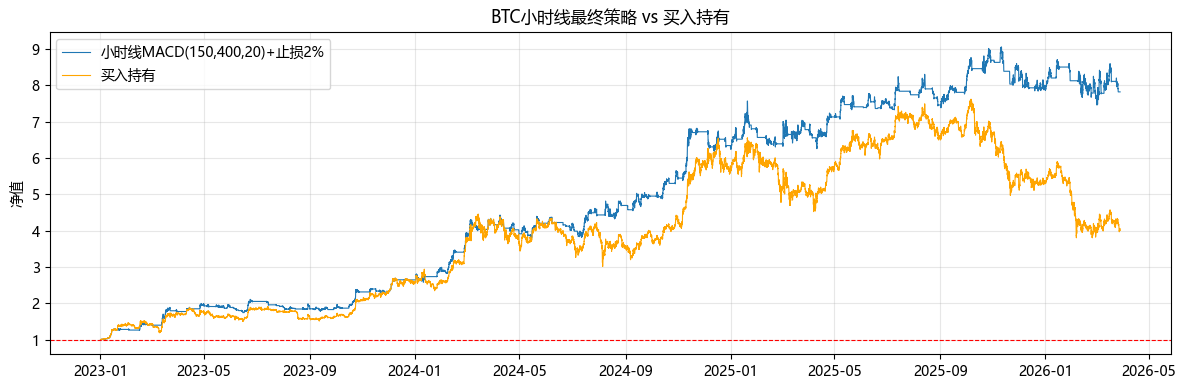

In [82]:
# 最优小时线策略
ef = close_1h.ewm(span=150, adjust=False).mean()
es = close_1h.ewm(span=400, adjust=False).mean()
m = ef - es
sl = m.ewm(span=20, adjust=False).mean()
cross_final = (m > sl).astype(float)

ret = close_1h.pct_change().dropna()
sig = cross_final.shift(1).dropna()
c = ret.index.intersection(sig.index)

pv_final = [1.0]
holding = 0
for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        pv_final.append(pv_final[-1])
        continue
    dr = ret.loc[date] * holding
    if dr < -0.02:
        dr = -0.02
        holding = 0
    else:
        holding = sig.loc[date]
    pv_final.append(pv_final[-1] * (1 + dr))

pv_final = pd.Series(pv_final[1:], index=c)
bh = (1 + ret[c]).cumprod()

total = pv_final.iloc[-1] - 1
sr = ret[c] * sig[c]
sharpe = sr.mean() / sr.std() * np.sqrt(8760)
dd = ((pv_final - pv_final.cummax()) / pv_final.cummax()).min()

print(f"小时线最终策略 累计收益：{total:.2%}")
print(f"小时线最终策略 Sharpe：{sharpe:.4f}")
print(f"小时线最终策略 最大回撤：{dd:.2%}")
print(f"买入持有 累计收益：{bh.iloc[-1]-1:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_final.index, pv_final, linewidth=0.8, label="小时线MACD(150,400,20)+止损2%")
plt.plot(bh.index, bh, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("BTC小时线最终策略 vs 买入持有")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [83]:
    # 统计交易次数
trade_count = (cross_final.diff() != 0).sum()
print(f"总信号切换次数：{trade_count}")
print(f"平均每年切换：{trade_count/(len(cross_final)/8760):.0f}次")
print(f"每次成本0.1%，总成本：{trade_count*0.001:.2%}")

总信号切换次数：331
平均每年切换：102次
每次成本0.1%，总成本：33.10%


扣成本前 累计收益：682.38%
扣成本后 累计收益：439.29%
成本侵蚀：243.09%
扣成本后 最大回撤：-20.50%


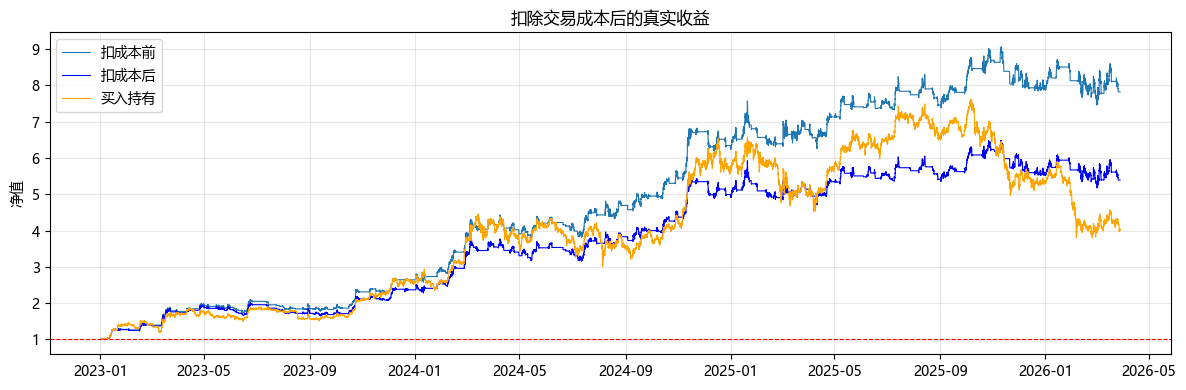

In [84]:
# 扣除交易成本后的净收益
cost_per_trade = 0.001  # 每次0.1%

pv_net = [1.0]
holding = 0

for i, date in enumerate(c):
    if i == 0:
        holding = sig.loc[date]
        pv_net.append(pv_net[-1])
        continue
    dr = ret.loc[date] * holding
    
    # 检查是否发生信号切换（产生交易成本）
    new_holding = sig.loc[date]
    if new_holding != holding and dr >= -0.02:
        dr -= cost_per_trade
    
    if dr < -0.02:
        dr = -0.02
        holding = 0
    else:
        holding = new_holding
    
    pv_net.append(pv_net[-1] * (1 + dr))

pv_net = pd.Series(pv_net[1:], index=c)
total_net = pv_net.iloc[-1] - 1
dd_net = ((pv_net - pv_net.cummax()) / pv_net.cummax()).min()

print(f"扣成本前 累计收益：{total:.2%}")
print(f"扣成本后 累计收益：{total_net:.2%}")
print(f"成本侵蚀：{total - total_net:.2%}")
print(f"扣成本后 最大回撤：{dd_net:.2%}")

plt.figure(figsize=(12, 4))
plt.plot(pv_final.index, pv_final, linewidth=0.8, label="扣成本前")
plt.plot(pv_net.index, pv_net, linewidth=0.8, label="扣成本后", color="blue")
plt.plot(bh.index, bh, linewidth=0.8, label="买入持有", color="orange")
plt.axhline(y=1, color="red", linewidth=0.8, linestyle="--")
plt.title("扣除交易成本后的真实收益")
plt.ylabel("净值")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
# 用日线数据做仓位管理
close = close_btc
ema_fast = close.ewm(span=16, adjust=False).mean()
ema_slow = close.ewm(span=35, adjust=False).mean()
macd_line = ema_fast - ema_slow
signal_line = macd_line.ewm(span=9, adjust=False).mean()

# MACD差值
diff = macd_line - signal_line

# 用滚动90日标准差归一化，把差值转成仓位
rolling_std = diff.rolling(90).std()
position = (diff / rolling_std).clip(-2, 2)  # 截断到-2到2之间

# 只做多：负值归零，正值线性映射到0-1
position_long = position.clip(0, 2) / 2  # 0到1之间

print(f"平均仓位：{position_long.mean():.2%}")
print(f"满仓天数比例：{(position_long>=0.99).mean():.2%}")
print(f"空仓天数比例：{(position_long==0).mean():.2%}")
print(position_long.tail())

平均仓位：21.19%
满仓天数比例：5.24%
空仓天数比例：48.94%
date
2026-03-24    0.131430
2026-03-25    0.152407
2026-03-26    0.082666
2026-03-27    0.000000
2026-03-28    0.000000
Name: close, dtype: float64


方式一 平均仓位：32.26%  空仓比例：48.94%
方式二(sigmoid) 平均仓位：30.49%  空仓比例：56.47%


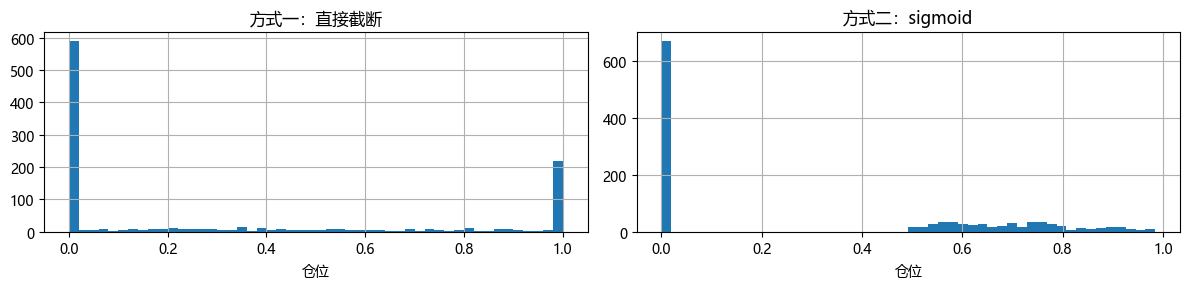

In [86]:
# 调整归一化，让仓位分布更合理
position2 = (diff / rolling_std).clip(0, 1)  # 正值直接作为仓位，截断到0-1

# 用sigmoid函数让仓位分布更均匀
import numpy as np
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

position3 = diff / rolling_std
position3 = position3.apply(lambda x: sigmoid(x) if x > 0 else 0)

print(f"方式一 平均仓位：{position2.mean():.2%}  空仓比例：{(position2==0).mean():.2%}")
print(f"方式二(sigmoid) 平均仓位：{position3.mean():.2%}  空仓比例：{(position3==0).mean():.2%}")

# 对比两种方式的仓位分布
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
position2.hist(bins=50, ax=axes[0])
axes[0].set_title("方式一：直接截断")
axes[0].set_xlabel("仓位")
position3.hist(bins=50, ax=axes[1])
axes[1].set_title("方式二：sigmoid")
axes[1].set_xlabel("仓位")
plt.tight_layout()
plt.show()

In [87]:
# 三档仓位：强信号满仓，弱信号半仓，负信号空仓
rolling_pct = diff.rolling(90).rank(pct=True)  # 当前差值在过去90天的百分位

position4 = pd.Series(0.0, index=diff.index)
position4[diff > 0] = 0.5                          # 正信号，半仓
position4[diff > 0 & (rolling_pct > 0.7)] = 1.0   # 强正信号（前30%），满仓

print(f"空仓天数：{(position4==0).mean():.2%}")
print(f"半仓天数：{(position4==0.5).mean():.2%}")
print(f"满仓天数：{(position4==1.0).mean():.2%}")

空仓天数：51.90%
半仓天数：0.00%
满仓天数：48.10%


In [88]:
# 修复版三档仓位
position4 = pd.Series(0.0, index=diff.index)
position4[diff > 0] = 0.5  # 正信号，半仓
position4[(diff > 0) & (rolling_pct > 0.7)] = 1.0  # 强正信号，满仓

print(f"空仓天数：{(position4==0).mean():.2%}")
print(f"半仓天数：{(position4==0.5).mean():.2%}")
print(f"满仓天数：{(position4==1.0).mean():.2%}")
print(f"平均仓位：{position4.mean():.2%}")

空仓天数：51.90%
半仓天数：16.23%
满仓天数：31.87%
平均仓位：39.98%
